# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [56]:
#Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3
#plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [57]:
#import from a giant csv
#csvpath = "/Volumes/AllieS/Morphology_data/"
csvpath = '/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs/'

filename = 'total_combined_cell.csv'
#filename = "total_combined_cell_borders_excluded.csv"
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(combined_cell_df_mitolyso.shape)
#print(cell_df.shape, " ", filter_df.shape)

#combined_cell_df_mitolyso_merged = plate_df_setup(curr_plates, curr_plate_datafolders, parent_dir, ['Cell.csv', 'Nuclei.csv','MergedMitoPerCell.csv','MergedLysoPerCell.csv'])

filename_borders_excluded = "total_combined_cell_borders_excluded.csv"
combined_cell_df_mitolyso_borders_excluded = pd.read_csv(os.path.join(csvpath, filename_borders_excluded))

/tmp/ipykernel_852/685987370.py:7: DtypeWarning: Columns (1305,1306,1463,1464,1511,1512,1564,1565,3389) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))


(75435, 3445)

/tmp/ipykernel_852/685987370.py:15: DtypeWarning: Columns (1305,1306,1463,1464,1511,1512,1564,1565,3389) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_cell_df_mitolyso_borders_excluded = pd.read_csv(os.path.join(csvpath, filename_borders_excluded))


In [ ]:
unique_combinations = combined_cell_df_mitolyso[['Replicate_Number', 'PassageNumber']].drop_duplicates()

combos = list(unique_combinations.itertuples(index=False, name=None))
#display(sorted(combos))
display(combined_cell_df_mitolyso)

## Debugging functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

In [59]:
def enforce_objects_one_to_one(
    df,
    parent_obj="Cell",
    child_obj="Nuclei",
    parent_colname="Cell_AreaShape_Area",
    child_colname="Cell_Mean_Nuclei_AreaShape_Area",
):
    """apply filters based on the number of nuclei to remove to enforce a 1:1 cell-nucleus relationship:
    - Cells that have less or more than one nucleus
    - Poorly segmented cells where the cell area is smaller than the nuclei area
    - Image is not flagged as empty by CellProfiler
    Can also use other objects instead of nuclei

    Args:
        df (DataFrame): The parent dataframe
        child_obj (str, optional): _description_. Defaults to "Nuclei".
        parent_colname (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        child_colname (str, optional): _description_. Defaults to "Cell_Mean_Nuclei_AreaShape_Area".

    Returns:
        DataFrame: the filtered dataframe with the removed objects
    """
    if child_obj == "Nuclei" and parent_obj == "Cell":
        try:
            not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
            normal_cells = not_empty_df[
                not_empty_df["Cell_Classify_one_nuc"] == 1
            ]  # one nucleus only
        except KeyError as e:
            print(f"KeyError {e}; skipping emptyimage")
            normal_cells = df[df["Cell_Classify_one_nuc"] == 1]
        # remove if my cell area is bigger than nuclear area
        size_filtered_cells = normal_cells[
            normal_cells[parent_colname] > normal_cells[child_colname]
        ]
        final_df = size_filtered_cells.reset_index(drop=True)
        return final_df
    else:
        # just do the size excludion
        not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
        size_filtered_cells = not_empty_df[
            not_empty_df[parent_colname] > not_empty_df[child_colname]
        ]
        return size_filtered_cells


def filter_nuclei_outisde_bbox(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_nuclei_with_bbox_overlap(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    if len(df[f"{nuc_prefix}_AreaShape_Area"]) != len(
        df[f"{cell_prefix}_AreaShape_Area"]
    ):
        return ValueError

    nuc_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"]
    )  # the diameter of the cell on x axis
    nuc_delta_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"]
    )  # the diameter of the cell on x axis

    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_out_empty_compartment_from_cells(df, organelle, prefix=""):
    """Remove rows from a dataframe where a parent "cell" object doesn't have any child objects of {organelle}

    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    organelle = organelle.title()
    this_df = df.copy()
    atleast_one_df = this_df[
        this_df[f"{prefix}Children_{organelle}_Count"] > 1
    ].reset_index(drop=True)
    return atleast_one_df


def hard_size_filter_rows_in_df(
    df,
    area_col="Nuclei_AreaShape_Area",
    prefix="",
    min_threshold=5000,
    max_threshold=np.inf,
):
    """Remove rows from a dataframe that are above a size theshold
    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    data_df = df.copy()
    data_df = data_df[data_df[prefix + area_col] > min_threshold]
    data_df = data_df[data_df[prefix + area_col] < max_threshold]
    final_df = data_df.reset_index(drop=True)
    return final_df


def filter_out_images_with_n_cells(
    df, n, image_count_col="Image_Count_Cell", prefix=""
):
    filter_df = df.copy()
    filter_df = filter_df[image_count_col] > n
    final_df = filter_df.reset_index(drop=True)
    return final_df


def apply_all_filters(
    df,
    nuc_size_min_threshold=5000,
    nuc_size_max_threshold=np.inf,
    cell_size_min_threshold=5000,
    cell_size_max_threshold=np.inf,
    cell_nuc_area_minthreshold=1,
    cell_nuc_area_maxthreshold=65532,
    min_cell_count=1,
    minimum_nucleus_intensity=0,
    maximum_nucleus_intensity=65532,
    cell_nuc_ratio_col="Cell_Nuclei_Area_Ratio",
    nuc_intensity_col="Nuclei_Intensity_MeanIntensity_DAPI_MAX",
    area_col="AreaShape_Area",
    nuc_area_col="Nuclei_AreaShape_Area",
    neighbours_col="Neighbors_PercentTouching_5",
    image_count_col="Image_Count_Cell",
):
    filtered_df = (
        df  # enforce_objects_one_to_one(df)  # , child_colname="Nuclei_AreaShape_Area")
    )
    filtered_df.columns = filtered_df.columns.str.replace(r"^Cell_", "", regex=True)
    filter_df_copy = filtered_df.copy()
    # also rename nuclei cols in the filtered df when you made the df one-to-one
    filter_df_copy.columns = filter_df_copy.columns.str.replace(
        r"^Mean_Nuclei_", "Nuclei_", regex=True
    )
    filter_df_copy["Cell_Nuclei_Area_Ratio"] = filter_df_copy[
        "Nuclei_Area_Ratio"
    ]  # dupe column with the old name back
    # filter out the cells wo compartments
    unique_ID_df = filter_df_copy.reset_index().rename(
        columns={"index": "Cell_Unique_ID"}  # add a unique ID
    )
    filter_df_1 = filter_out_empty_compartment_from_cells(unique_ID_df, "mitochondria")
    filter_df_2 = filter_out_empty_compartment_from_cells(filter_df_1, "lysosomes")
    filter_df_nuclei_minintensity = filter_df_2[
        filter_df_2[nuc_intensity_col] > minimum_nucleus_intensity
    ]
    filter_df_nuclei_maxintensity = filter_df_nuclei_minintensity[
        filter_df_nuclei_minintensity[nuc_intensity_col] < maximum_nucleus_intensity
    ]
    filter_df_morethanonecell = filter_df_nuclei_maxintensity.copy()[
        filter_df_nuclei_maxintensity[image_count_col] > min_cell_count
    ]
    # filter_df_outbbox = filter_nuclei_outisde_bbox(filter_df_morethanonecell)
    filter_df_nuc_size = hard_size_filter_rows_in_df(
        filter_df_morethanonecell,
        min_threshold=nuc_size_min_threshold,
        max_threshold=nuc_size_max_threshold,
        area_col=nuc_area_col,
        prefix="",
    )
    filter_df_cell_size = hard_size_filter_rows_in_df(
        filter_df_nuc_size,
        min_threshold=cell_size_min_threshold,
        max_threshold=cell_size_max_threshold,
        area_col=area_col,
        prefix="",
    )
    filter_df_maxratio = filter_df_cell_size.copy()[
        filter_df_cell_size[cell_nuc_ratio_col] < cell_nuc_area_maxthreshold
    ]
    filter_df_minratio = filter_df_maxratio[
        filter_df_maxratio[cell_nuc_ratio_col] > cell_nuc_area_minthreshold
    ]
    filter_df_neigbours = filter_df_minratio[
        filter_df_minratio[neighbours_col] < 99
    ]  # optional filter for touching neighbors
    final_filtered_df = (
        filter_df_neigbours.copy()
    )  # or filter_df_size if you want the size filter
    # Create a dictionary to store filtering summary
    filtering_summary = {
        "OG_df": {
            "filter_type": "Original",
            "rows": df.shape[0],
            "columns": df.shape[1],
            "rows_removed": 0,
        },
        "Filtered_df": {
            "filter_type": "Initial Column Filter",
            "rows": filtered_df.shape[0],
            "columns": filtered_df.shape[1],
            "rows_removed": df.shape[0] - filtered_df.shape[0],
        },
        "Empty_Mitochondria_Removed": {
            "filter_type": "Remove Empty Mitochondria",
            "rows": filter_df_1.shape[0],
            "columns": filter_df_1.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_1.shape[0],
        },
        "Empty_Lysosomes_Removed": {
            "filter_type": "Remove Empty Organelles",
            "rows": filter_df_2.shape[0],
            "columns": filter_df_2.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_2.shape[0],
        },
        "Nuclei_Min_Intensity_Filtered": {
            "filter_type": "Nuclei Minimum Intensity",
            "rows": filter_df_nuclei_minintensity.shape[0],
            "columns": filter_df_nuclei_minintensity.shape[1],
            "rows_removed": filter_df_2.shape[0]
            - filter_df_nuclei_minintensity.shape[0],
        },
        "Nuclei_Max_Intensity_Filtered": {
            "filter_type": "Nuclei Maxiumum Intensity",
            "rows": filter_df_nuclei_maxintensity.shape[0],
            "columns": filter_df_nuclei_maxintensity.shape[1],
            "rows_removed": filter_df_nuclei_minintensity.shape[0]
            - filter_df_nuclei_maxintensity.shape[0],
        },
        "More_Than_One_Cell": {
            "filter_type": "More Than One Cell",
            "rows": filter_df_morethanonecell.shape[0],
            "columns": filter_df_morethanonecell.shape[1],
            "rows_removed": filter_df_nuclei_maxintensity.shape[0]
            - filter_df_morethanonecell.shape[0],
        },
        "Nuc_Size_Thresholded": {
            "filter_type": "Nuclei Size Threshold",
            "rows": filter_df_nuc_size.shape[0],
            "columns": filter_df_nuc_size.shape[1],
            "rows_removed": filter_df_morethanonecell.shape[0]
            - filter_df_nuc_size.shape[0],
        },
        "Cell_Size_Thresholded": {
            "filter_type": "Cell Size Threshold",
            "rows": filter_df_cell_size.shape[0],
            "columns": filter_df_cell_size.shape[1],
            "rows_removed": filter_df_nuc_size.shape[0] - filter_df_cell_size.shape[0],
        },
        "Cell_Nuclei_Ratio_MinFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_maxratio.shape[0],
            "columns": filter_df_maxratio.shape[1],
            "rows_removed": filter_df_cell_size.shape[0] - filter_df_maxratio.shape[0],
        },
        "Cell_Nuclei_Ratio_MaxFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_minratio.shape[0],
            "columns": filter_df_minratio.shape[1],
            "rows_removed": filter_df_maxratio.shape[0] - filter_df_minratio.shape[0],
        },
        "Neighbors_Filtered": {
            "filter_type": "Neighbors Percent Touching < 99",
            "rows": filter_df_neigbours.shape[0],
            "columns": filter_df_neigbours.shape[1],
            "rows_removed": filter_df_minratio.shape[0] - filter_df_neigbours.shape[0],
        },
        "Final_Filtered_df": {
            "filter_type": "Final Filtered DataFrame",
            "rows": final_filtered_df.shape[0],
            "columns": final_filtered_df.shape[1],
            "rows_removed": filter_df_neigbours.shape[0] - final_filtered_df.shape[0],
        },
    }

    # export as CSV
    pd.DataFrame.from_dict(filtering_summary, orient="index").to_csv(
        "filtering_summary.csv"
    )

    return final_filtered_df


final_filtered_df = apply_all_filters(combined_cell_df_mitolyso)


In [60]:
#test out the colour dict
colour_dict = get_hard_code_replicate_colours(final_filtered_df)
# display(colour_dict)
# print(colour_dict[6])
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Replicate_Number", palette=colour_dict)

In [71]:
colnames = search_column_name(final_filtered_df,"Number")
display(final_filtered_df[colnames])

Query: Number
    ImageNumber
    Number_Object_Number
    AreaShape_EulerNumber
    Mean_Lysosomes_AreaShape_EulerNumber
    Mean_Lysosomes_Number_Object_Number
    Mean_MitoEnds_Number_Object_Number
    Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton
    Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn
    Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton
    Mean_Mitochondria_AreaShape_EulerNumber
    Mean_Mitochondria_Number_Object_Number
    Mean_Mitochondria_Puncta_AreaShape_EulerNumber
    Mean_Mitochondria_Puncta_Number_Object_Number
    Neighbors_FirstClosestObjectNumber_5
    Neighbors_NumberOfNeighbors_5
    Neighbors_SecondClosestObjectNumber_5
    Image_Group_Number
    Nuclei_Number_Object_Number
    Nuclei_AreaShape_EulerNumber
    Nuclei_Neighbors_FirstClosestObjectNumber_1
    Nuclei_Neighbors_NumberOfNeighbors_1
    Nuclei_Neighbors_SecondClosestObjectNumber_1
    Nuclei_ObjectSkeleton_NumberBranchEnds_MitoSkeleton
    Nuclei_ObjectSkeleton_

,ImageNumber,Number_Object_Number,AreaShape_EulerNumber,Mean_Lysosomes_AreaShape_EulerNumber,Mean_Lysosomes_Number_Object_Number,Mean_MitoEnds_Number_Object_Number,Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton,Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn,Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton,Mean_Mitochondria_AreaShape_EulerNumber,...,Nuclei_ObjectSkeleton_NumberNonTrunkBranches_MitoSkeleton,Nuclei_ObjectSkeleton_NumberTrunks_MitoSkeleton,Cytoplasm_Number_Object_Number,Cytoplasm_AreaShape_EulerNumber,CellNumber_ImageNumber_Index,Median_Lysosomes_AreaShape_EulerNumber,Median_Mitochondria_AreaShape_EulerNumber,SerialPassage_BatchNumber,PassageNumber,Replicate_Number
0,98,1,1.0,1.0,445.754545,406.496269,0.194030,0.235075,1.037313,0.946136,...,34,26,1,0.0,1_98,1.0,1.0,8,16,6
1,98,2,1.0,1.0,955.527919,890.750000,0.308824,0.730392,1.078431,0.628205,...,56,34,2,0.0,2_98,1.0,1.0,8,16,6
2,97,1,1.0,1.0,865.925118,1136.626991,0.298230,0.241150,1.084956,0.963158,...,52,43,1,0.0,1_97,1.0,1.0,8,16,6
3,97,2,1.0,1.0,2043.669261,2507.592661,0.337615,0.339450,1.089908,0.901361,...,26,26,2,0.0,2_97,1.0,1.0,8,16,6
4,105,1,1.0,1.0,614.297974,628.559364,0.365973,0.472460,1.084455,0.852657,...,4,15,1,0.0,1_105,1.0,1.0,8,16,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74415,1199,8,1.0,1.0,1287.131579,1281.835616,0.383562,0.109589,1.095890,0.979167,...,28,16,8,0.0,8_1199,1.0,1.0,5,6,1
74416,1199,9,1.0,1.0,1355.355140,1349.269663,0.438202,0.438202,1.146067,0.897959,...,13,10,9,0.0,9_1199,1.0,1.0,5,6,1
74417,1199,10,1.0,1.0,1588.133333,1570.775194,0.480620,0.310078,1.131783,0.948052,...,6,16,10,0.0,10_1199,1.0,1.0,5,6,1
74418,1200,1,1.0,1.0,94.315508,39.000000,0.545455,0.220779,1.233766,1.000000,...,4,6,1,0.0,1_1200,1.0,1.0,5,6,1


In [62]:
#display(combined_cell_df_mitolyso[['Cell_AreaShape_Area', 'Cell_Children_Mitochondria_Count','Cell_Mean_Mitochondria_AreaShape_Area']])
display(final_filtered_df[['AreaShape_Area', 'Children_Mitochondria_Count','Mean_Mitochondria_AreaShape_Area']])

,AreaShape_Area,Children_Mitochondria_Count,Mean_Mitochondria_AreaShape_Area
0,477796.0,427,137.892272
1,116904.0,78,245.525641
2,982750.0,1330,100.042105
3,241819.0,294,150.227891
4,277600.0,414,162.929952
...,...,...,...
74415,38208.0,48,54.979167
74416,39024.0,49,107.285714
74417,47936.0,77,93.571429
74418,63532.0,54,53.611111



# Define the cell features


In [63]:
# Add extra columns
def proportion_area_occupied_per_cell(df, compartment):
    # proportion of area occupied = children * mean organelle area / cell area
    colname = "Total_Area_Proportion_" + compartment + "_Per_Cell"

    # children = 'Children_' + compartment + '_Count'
    # mean_organelle_area = 'Mean_'+ compartment + '_AreaShape_Area'
    organelle_area = compartment + "_AreaShape_Area"
    cell_area = "AreaShape_Area"
    # df[colname] = df.apply(lambda x: (x[children] * x[mean_organelle_area]) / x[cell_area], axis=1)
    df[colname] = df.apply(lambda x: (x[organelle_area]) / x[cell_area], axis=1)
    return df[colname]


def mean_intensity_per_compartment_per_cell(df, compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    # mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = f"Mean_Intensity_Per_{compartment} Per_Cell"
    integrated = "Intensity_IntegratedIntensity_" + tag
    # children = 'Children_' + compartment + '_Count'
    # mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + "_AreaShape_Area"
    total_organelle_area = math if math is not None else total_organelle_area

    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)

    return df[colname]


# df["Mean_Mitochondria_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(combined_cell_df_mitolyso_merged, "MergedMitoPerCell")
# df["Mean_Lysosomes_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(df, "MergedLysoPerCell")

# df["MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(combined_cell_df_mitolyso_merged, "Lysosomes", "MergedLysoPerCell", "LAMP1")
# df["MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(df, "Mitochondria", "MergedMitoPerCell", "MitoTracker")


# Calculate the total area occupied by mitochondria and lysosomes per cell
def calculate_corrected_features(full_df):
    """_summary_

    Args:
        full_df (DataFrame): _description_

    Returns:
        df (DataFrame): the df with all the feature calcs
    """
    df = full_df.copy()
    df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Count"] * df["Mean_Mitochondria_AreaShape_Area"]
    )
    df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] = (
        df["Children_Lysosomes_Count"] * df["Mean_Lysosomes_AreaShape_Area"]
    )
    df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Puncta_Count"]
        * df["Mean_Mitochondria_Puncta_AreaShape_Area"]
    )

    # Total intensity per cell based on integrated instensity if I don't already have the merged area
    df["Mean_Intensity_Per_Lysosomes_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Lysosomes",
            "MergedLysoPerCell",
            "LAMP1",
            math="Math_Total_Lysosomes_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria",
            "MergedMitoPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_Puncta_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria_Puncta",
            "MergedMitoPunctaPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell",
        )
    )
    # #same thing but for medians
    # df["Median_Intensity_Per_Lysosomes_PerCell_Area"] = (
    #     df["Children_Lysosomes_Count"]
    #     * df["Mean_Lysosomes_Intensity_MeanIntensity_LAMP1"]
    # )
    # df["Median_Intensity_Per_Mitochondria_PerCell_Area"] = (
    #     df["Children_Mitochondria_Count"]
    #     * df["Mean_Mitochondria_Intensity_MeanIntensity_MitoTracker"]
    # )

    # Corrected mitochondria and lysosomes counts per cell area (density)
    df["Density_Children_Mitochondria_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Lysosomes_Count_PerCell_Area"] = (
        df["Children_Lysosomes_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Mitochondria_Puncta_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Puncta_Count"] / df["AreaShape_Area"]
    )

    # organelle area fractions per cell ratio
    df["OccupiedAreaFraction_Mitochondria_PerCell_Area"] = (
        df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Mitochondria_Puncta_PerCell_Area"] = (
        df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"]
        / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Lysosomes_PerCell_Area"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )

    # Compartment diameter ratios
    df["Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Mean_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Mitochondria_DiameterRatio_PerCell"] = (
        df["Median_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Median_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Lysosomes_DiameterRatio_PerCell"] = (
        df["Median_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Median_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_Puncta_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    )
    # df["Median_Mitochondria_Puncta_DiameterRatio_PerCell"] = (
    #     df["Median_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
    #     / df["Median_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    # )

    # mean and median area per organelle per cell area
    df["Mean_Mitochondria_Area_PerCell_Area"] = (
        df["Mean_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Area_PerCell_Area"] = (
        df["Mean_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta)Area_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Mitochondria_Area_PerCell_Area"] = (
        df["Median_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Lysosomes_Area_PerCell_Area"] = (
        df["Median_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )

    # mitolyso related
    df["Children_Lysosomes_Mitochondria_Ratio"] = (
        df["Children_Lysosomes_Count"] / df["Children_Mitochondria_Count"]
    )
    df["Density_Lysosomes_Mitochondria_Ratio"] = (
        df["OccupiedAreaFraction_Lysosomes_PerCell_Area"]
        / df["OccupiedAreaFraction_Mitochondria_PerCell_Area"]
    )
    df["Area_Lysosomes_Mitochondria_Ratio"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"]
        / df["Math_Total_Mitochondria_AreaShape_Area_PerCell"]
    )

    # Quin's Ratio: Ratio of centroid distance to minimum distance for mitochondria and lysosomes
    # increase = more peripheral, decrease = more nuclear
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Nuclei"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Cell"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Cell"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"]
    )
    # Distance to parents percellarea
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    # transform the mitoends - number of ends times the mean to get total per cell
    df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"]
    )
    df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn"]
    )
    df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton"]
    )
    df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_TotalObjectSkeltnLngth_MtSkltn"]
    )
    # now divide these by cell area
    df["MitoEnds_NumberBranchEnds_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberNonTrunkBranches_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberTrunks_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_TotalObjectSkeltnLngth_PerCell_Area"] = (
        df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] / df["AreaShape_Area"]
    )

    # also the nuclear mito skeleton features per cell area
    df["Nuclei_ObjectSkeleton_NumberBranchEnds_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberTrunks_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkeleton"]
        / df["AreaShape_Area"]
    )

    return df


combined_cell_df_mitolyso_merged = calculate_corrected_features(final_filtered_df)
# display(combined_cell_df_mitolyso_merged)


In [64]:
display(
    combined_cell_df_mitolyso_merged[
        [
            "Children_Mitochondria_Count",
            "Mean_Mitochondria_AreaShape_Area",
            "Math_Total_Mitochondria_AreaShape_Area_PerCell",
            "Median_Mitochondria_Area_PerCell_Area",
            "Mean_Mitochondria_Area_PerCell_Area",
            "OccupiedAreaFraction_Mitochondria_PerCell_Area",
            "Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell",
            "Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio",
            "Density_Children_Mitochondria_Count_PerCell_Area",
            "Mean_Intensity_Per_Mitochondria_PerCell_Area",
        ]
    ]
)


# Note: use the "Corr_" flag to get the corrected values
# display(combined_cell_df_mitolyso_merged[["Passage Group","Mean_Lysosomes_Intensity_MeanIntensity_LAMP1","MeanIntensity_Mitochondria_PerCell_Ratio","MeanIntensity_Lysosomes_PerCell_Ratio","Mean_Lysosomes_Area_PerCell_Ratio","Mean_Mitochondria_Area_PerCell_Ratio","Math_Total_Mitochondria_AreaShape_Area_PerCell","Math_Total_Lysosomes_AreaShape_Area_PerCell"]])

,Children_Mitochondria_Count,Mean_Mitochondria_AreaShape_Area,Math_Total_Mitochondria_AreaShape_Area_PerCell,Median_Mitochondria_Area_PerCell_Area,Mean_Mitochondria_Area_PerCell_Area,OccupiedAreaFraction_Mitochondria_PerCell_Area,Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell,Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio,Density_Children_Mitochondria_Count_PerCell_Area,Mean_Intensity_Per_Mitochondria_PerCell_Area
0,427,137.892272,58880.0,0.000163,0.000289,0.123233,1.468216,1.651939,0.000894,18118.531165
1,78,245.525641,19151.0,0.000590,0.002100,0.163818,1.506242,1.814744,0.000667,18017.654483
2,1330,100.042105,133056.0,0.000065,0.000102,0.135392,1.488197,1.831683,0.001353,14602.180894
3,294,150.227891,44167.0,0.000318,0.000621,0.182645,1.543979,2.055211,0.001216,13571.847239
4,414,162.929952,67453.0,0.000252,0.000587,0.242986,1.520909,1.648469,0.001491,13972.891139
...,...,...,...,...,...,...,...,...,...,...
74415,48,54.979167,2639.0,0.000929,0.001439,0.069069,1.495085,5.199959,0.001256,19782.491474
74416,49,107.285714,5257.0,0.001589,0.002749,0.134712,1.518828,3.432601,0.001256,10164.995244
74417,77,93.571429,7205.0,0.001043,0.001952,0.150305,1.552327,2.471480,0.001606,9495.874532
74418,54,53.611111,2895.0,0.000567,0.000844,0.045568,1.474131,4.419312,0.000850,29283.876339


In [65]:
# file_path = '/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/Cellcsv_columns.txt'
# pairs_samples = [('P6-8', 'P9-10'), ('P6-8', 'P11-13'), ('P6-8', 'P14-16'), ('P6-8', 'P17-18'),
# ('P6-8', 'P20-21'), ('P6-8', 'P22-24'), ('P9-10', 'P11-13'), ('P9-10', 'P14-16'), ('P9-10', 'P17-18'),
# ('P9-10', 'P20-21'), ('P9-10', 'P22-24'), ('P11-13', 'P14-16'), ('P11-13', 'P17-18'), ('P11-13',
# 'P20-21'), ('P11-13', 'P22-24'), ('P14-16', 'P17-18'), ('P14-16', 'P20-21'), ('P14-16', 'P22-24'),
# ('P17-18', 'P20-21'), ('P17-18', 'P22-24'), ('P20-21', 'P22-24')]
columns_list = define_cell_features(combined_cell_df_mitolyso_merged)


def define_cell_features(df):
    # Get the columns of the dataframe
    columns_list = df.columns.tolist()
    columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    old_columns_list = columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col and "FileName" not in col and "PathName" not in col
    ]
    print(
        "Original columns:",
        len(old_columns_list),
        "Filtered columns:",
        len(columns_list),
    )
    return columns_list


mito_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Mito" in col or "Mitochondria" in col)
        and ("DAPI" not in col and "LAMP1" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
lyso_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Lysosome" in col or "LAMP1" in col or "Lyso" in col)
        and ("DAPI" not in col and "Mito" not in col and "Frame" not in col)
        and not(col.startswith("Nuclei_"))
    ]
)
nuc_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Nuc" in col or "DAPI" in col)
        and ("MitoTracker" not in col and "LAMP1" not in col and "Frame" not in col)
    ]
)
cell_features = make_feature_dict(
    [
        col
        for col in columns_list
        if "AreaShape" in col
        and "Mito" not in col
        and "Lyso" not in col
        and "LAMP1" not in col
        and "Nuc" not in col
        and "DAPI" not in col
        and "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
    ]
)
print(columns_list)


['Cell_Unique_ID', 'ImageNumber', 'Number_Object_Number', 'AreaShape_Area', 'AreaShape_BoundingBoxArea', 'AreaShape_BoundingBoxMaximum_X', 'AreaShape_BoundingBoxMaximum_Y', 'AreaShape_BoundingBoxMinimum_X', 'AreaShape_BoundingBoxMinimum_Y', 'AreaShape_Center_X', 'AreaShape_Center_Y', 'AreaShape_Compactness', 'AreaShape_ConvexArea', 'AreaShape_Eccentricity', 'AreaShape_EquivalentDiameter', 'AreaShape_EulerNumber', 'AreaShape_Extent', 'AreaShape_FormFactor', 'AreaShape_MajorAxisLength', 'AreaShape_MaxFeretDiameter', 'AreaShape_MaximumRadius', 'AreaShape_MeanRadius', 'AreaShape_MedianRadius', 'AreaShape_MinFeretDiameter', 'AreaShape_MinorAxisLength', 'AreaShape_Orientation', 'AreaShape_Perimeter', 'AreaShape_Solidity', 'AreaShape_Zernike_0_0', 'AreaShape_Zernike_1_1', 'AreaShape_Zernike_2_0', 'AreaShape_Zernike_2_2', 'AreaShape_Zernike_3_1', 'AreaShape_Zernike_3_3', 'AreaShape_Zernike_4_0', 'AreaShape_Zernike_4_2', 'AreaShape_Zernike_4_4', 'AreaShape_Zernike_5_1', 'AreaShape_Zernike_5_3',

## Feature lists here:

In [66]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = ["Mitochondria Features", "Lysosome Features", "Nucleus Features", "Cell Features"]

# Define the output file path
output_file_path = 'allfeatures_file.md'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f"\"{feature}\",\n")
            file.write("\n")
            
print(f"List has been written to {output_file_path}")


List has been written to allfeatures_file.md


## Check if there are any mixed types hiding out

In [67]:
#Debug to check for mixed types in columns
for col in combined_cell_df_mitolyso_merged.columns:
    types = combined_cell_df_mitolyso_merged[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Column '{col}' has mixed types: {types}")

Column 'Image_FileName_Phalloidin' has mixed types: Image_FileName_Phalloidin
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_FileName_Phalloidin_MAX' has mixed types: Image_FileName_Phalloidin_MAX
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_MD5Digest_Phalloidin' has mixed types: Image_MD5Digest_Phalloidin
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_MD5Digest_Phalloidin_MAX' has mixed types: Image_MD5Digest_Phalloidin_MAX
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_PathName_Phalloidin' has mixed types: Image_PathName_Phalloidin
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_PathName_Phalloidin_MAX' has mixed types: Image_PathName_Phalloidin_MAX
<class 'str'>      61905
<class 'float'>    12447
Name: count, dtype: int64
Column 'Image_URL_Phalloidin' has mixed types: I

# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

## Trying out the pivot and groupby functions & outlier filtering


In [68]:
import scikit_posthocs as sp
def flag_outliers_by_group_mad(df, group_col, feature_col):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """
    df = df.copy()
    df["Outlier"] = df.groupby(group_col)[feature_col].transform(
        lambda x: pg.madmedianrule(x)
    )
    return df


def flag_outliers_by_group_gesd(df, group_col, feature_col, noutliers=20, report=True):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """

    df = df.copy()
    df["Outlier_GESD"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_gesd(x, outliers=noutliers, hypo=True, report=report)
    )
    return df

def flag_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Adds a boolean 'Outlier_Grubbs' column to df, True if you reject the null hypothesis that the extreme value is an outlier.
    """

    df = df.copy()
    df["Outlier_Tietjen"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_tietjen(x, k=noutliers, hypo=True)
    )
    return df

def remove_outliers_by_group_gesd(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using the GEST test.
    Returns a DataFrame with outliers removed.
    """
   
    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_gesd(group_df[feature_col], outliers=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df

def remove_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using Tietjen's test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_tietjen(group_df[feature_col], k=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


## Quality Control Image Lookup

In [69]:
import operator
df_to_filter = final_filtered_df.copy()

def get_mini_filtered_df(
    final_filtered_df,
    condition_col="",
    valueslist=[
        "Cell_Unique_ID",
        "ImageNumber",
        "TimepointName",
        "Metadata_WellRow",
        "Metadata_WellColumn",
        "Metadata_Field",
        "AllGroups",
        "Replicate_Number",
        "SerialPassage_BatchNumber",
        "AgeGroup",
        "PassageNumber",
        "Number_Object_Number",
        "AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Children_Mitochondria_Count",
        "Children_Lysosomes_Count",
        "Image_Width_DAPI",
        "Image_URL_MitoTracker_MAX",
        "Image_FileName_MitoTracker_MAX",
        "Image_FileName_LAMP1_MAX",
    ],
    op=operator.le,
    condition_value=10,
):
    mini_df = final_filtered_df[valueslist]

    mini_df["Metadata_Rep_RowColField"] = (
        "R"
        + mini_df["Replicate_Number"].astype(str)
        + "_r"
        + mini_df["Metadata_WellRow"].astype(str)
        + "c"
        + mini_df["Metadata_WellColumn"].astype(str)
        + "f"
        + mini_df["Metadata_Field"].astype(str)
        + ""
    )

    # Now add the filter
    filter_mini_df = mini_df[op(mini_df[condition_col], condition_value)]
    filter_mini_df_sorted = filter_mini_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)

    # reduce cols for readability
    filter_mini_df_display = filter_mini_df_sorted[
        ["AllGroups", "Replicate_Number", "Cell_Unique_ID", "Image_FileName_MitoTracker_MAX", condition_col]
    ]

    display(filter_mini_df_display)
    
    return filter_mini_df_sorted


def find_replicate_cp_output_folder(path):
    import re

    replicate_pattern = r"_rep0(\d{1})_"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(replicate_pattern, path)
    if match:
        replicate = int(match.group(1))
    else:
        replicate = None
    return replicate


def pull_up_cp_segmentation_image(img_filename, parent_dir="~/", replicate=0, group="", object_key=None, df=None):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    Can also highlight the sepecific object with a bounding box

    Args:
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_. 
        replicate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """    
    # Loop over the plates
    # make sure the filename in the format of: "Image_FileName_MitoTracker_MAX"
    from matplotlib import image as mpimg
    from PIL import Image

    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext in filename
                and filename.endswith(".png")
                and "active" in root
                and replicate == find_replicate_cp_output_folder(root)
            ):
                img_path = os.path.join(
                    root, img_filename_noext + ".png"
                )  # make the path
                try:
                    
                    img = Image.open(img_path)
                    fig,ax = plt.subplots(figsize=(8, 8))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"R{replicate}, {filename}, {group}")
                    
                    if object_key is not None and df is not None:
                        row = df[df["Cell_Unique_ID"] == object_key]
                        if not row.empty:
                            rect, filename_2 = get_image_and_object_coordinates(
                                df, object_key
                            )
                            ax.add_patch(rect)
                        else:
                            print(f"Object number {object_key} not found in dataframe.")              
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()

                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
            # else:
            #     print(filename, img_filename_noext)
def pull_up_cp_segmentation_image_fromID(
    df, object_key, parent_dir="", replicate_col_name ="Replicate_Number", feature = "", image_channel = "LAMP1", save=False, savepath=""
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        replicate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    #get the filename, replicate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df,object_key)
        
        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filename = unique_row[f"Image_FileName_{image_channel}_MAX"].values[0]
        replicate = unique_row[replicate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    #loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename 
                and filename.endswith(".png")
                and "active" in root #active cp output folder
                and replicate == find_replicate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root, filename#img_filename_noext + ".png"
                )  # make the path
                #Now we see if the image exists and try to open it
                try: 
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"ID:{object_key}, R{replicate} P{passage}, {filename}, {group}")
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    #add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        plt.savefig(f"{savepath}/R{replicate}_P{passage}_{filename}_{object_key}.png", bbox_inches='tight')
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False
    
def get_object_bbox_coordinates_as_rectangle(
    df,
    unique_ID,
    coord_cols=[
        "AreaShape_BoundingBoxMaximum_X",
        "AreaShape_BoundingBoxMaximum_Y",
        "AreaShape_BoundingBoxMinimum_X",
        "AreaShape_BoundingBoxMinimum_Y",
    ],
):
    from matplotlib import patches
    row = df[df["Cell_Unique_ID"] == unique_ID]
    if not row.empty:
        x_min = row["AreaShape_BoundingBoxMinimum_X"].values[0]
        y_min = row["AreaShape_BoundingBoxMinimum_Y"].values[0]
        x_max = row["AreaShape_BoundingBoxMaximum_X"].values[0]
        y_max = row["AreaShape_BoundingBoxMaximum_Y"].values[0]
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none'
        )
    return rect
    

def query_group_replicate_condition(df, group, replicate_number=0, condition_col="", op=operator.eq, value=None):
    """
    Filter df by group, replicate_number, and a condition using a passed operator.
    Example: op=operator.lt for '<', op=operator.gt for '>', op=operator.eq for '=='
    """
    mask = (
        (df["AllGroups"] == group) &
        (df["Replicate_Number"] == replicate_number) &
        (op(df[condition_col], value))
    )
    return df[mask]



In [72]:
feature_meas = "Nuclei_AreaShape_Area"
group = "P26-28"
condition_value=0
display(
    query_group_replicate_condition(
        df_to_filter, group, replicate_number= 7, condition_col=feature_meas, op=operator.ge, value=condition_value
    ).shape
)
# filtered_df_to_filter = df_to_filter[df_to_filter["AllGroups"]==group]
filtered_df_to_filter = df_to_filter.copy()

mini_filter_df = get_mini_filtered_df(
    final_filtered_df,
    condition_col=feature_meas,
    op=operator.ge,
    valueslist=final_filtered_df.columns.tolist(),
    condition_value=condition_value,
)
index_code = 0
# pull_up_cp_segmentation_image(
#     mini_filter_df["Image_FileName_LAMP1_MAX"][index_code],
#     "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
#     mini_filter_df["Replicate_Number"][index_code],
#     mini_filter_df["AllGroups"][index_code],
#     object_key=37170,
#     df=df_to_filter,
# )
# NOTE there are definitley more cells in p23-25 group - size biasing potentially?
valueslist = [
    "Cell_Unique_ID",
    "ImageNumber",
    "TimepointName",
    "Metadata_WellRow",
    "Metadata_WellColumn",
    "Metadata_Field",
    "AllGroups",
    "Replicate_Number",
    "SerialPassage_BatchNumber",
    "AgeGroup",
    "PassageNumber",
    "Number_Object_Number",
    "AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Children_Mitochondria_Count",
    "Children_Lysosomes_Count",
    "Image_Width_DAPI",
    "Image_URL_MitoTracker_MAX",
    "Image_FileName_MitoTracker_MAX",
    "Image_FileName_LAMP1_MAX",
    "Nuclei_Number_Object_Number",
    "Number_Object_Number",
]


(498, 3447)

,AllGroups,Replicate_Number,Cell_Unique_ID,Image_FileName_MitoTracker_MAX,Nuclei_AreaShape_Area
0,P6-10,3,58878,MAX_ch2-r03c07f19.tif,20640.0
1,P6-10,3,58896,MAX_ch2-r03c07f20.tif,12012.0
2,P6-10,3,58897,MAX_ch2-r03c07f20.tif,19576.0
3,P6-10,3,58866,MAX_ch2-r03c07f14.tif,20016.0
4,P6-10,3,58867,MAX_ch2-r03c07f14.tif,16184.0
...,...,...,...,...,...
74347,Doxo,6,35,MAX_ch2-r01c05f27.tif,16400.0
74348,Doxo,6,32,MAX_ch2-r01c05f26.tif,20228.0
74349,Doxo,6,31,MAX_ch2-r01c05f26.tif,13364.0
74350,Doxo,6,34,MAX_ch2-r01c05f27.tif,12912.0


MAX_ch2-r04c11f35.png


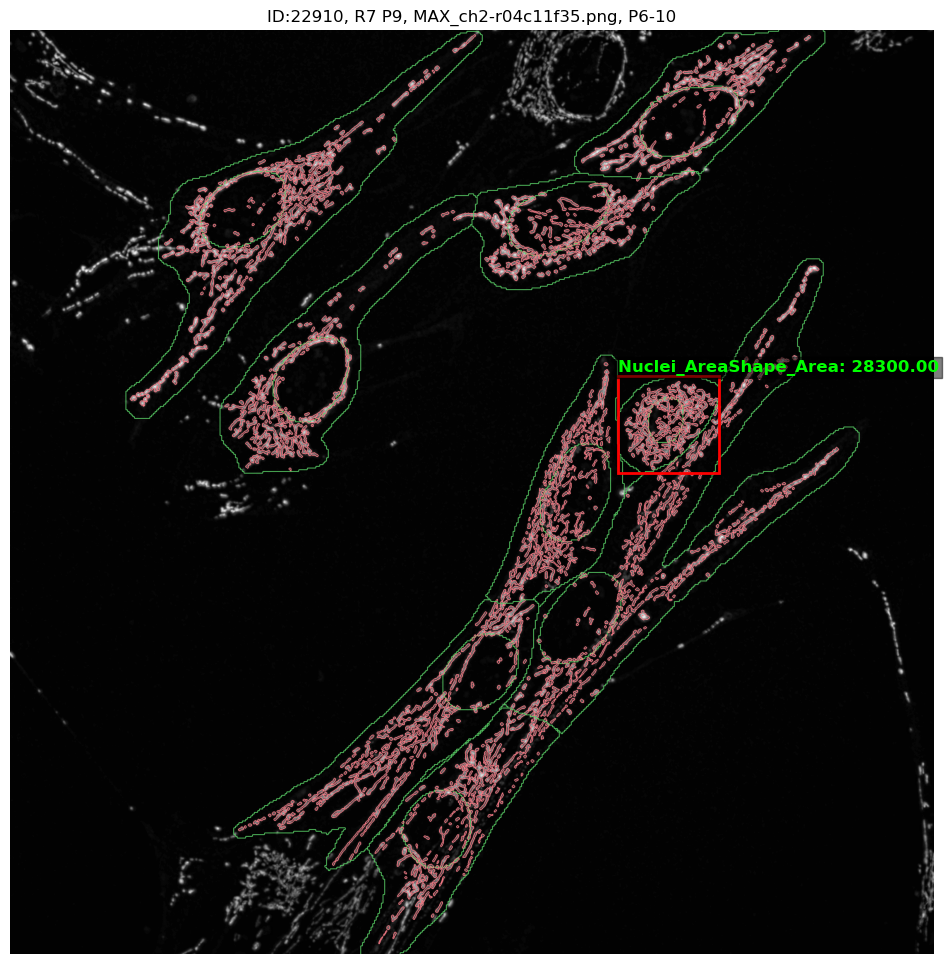

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250501_rep07_output/v4_active/MAX_ch2-r04c11f35.png
MAX_ch1-r04c11f35.png


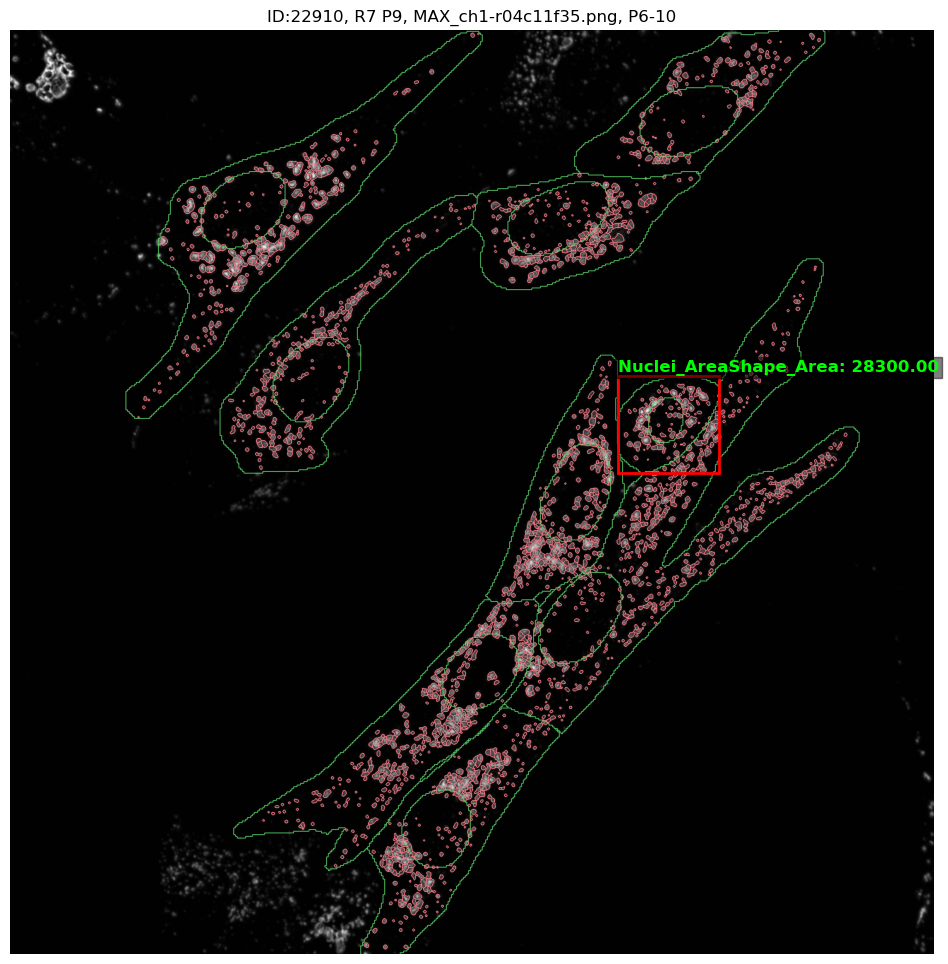

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250501_rep07_output/v4_active/MAX_ch1-r04c11f35.png


,Cell_Unique_ID,ImageNumber,TimepointName,Metadata_WellRow,Metadata_WellColumn,Metadata_Field,AllGroups,Replicate_Number,SerialPassage_BatchNumber,AgeGroup,...,AreaShape_Area,Cell_Nuclei_Area_Ratio,Children_Mitochondria_Count,Children_Lysosomes_Count,Image_Width_DAPI,Image_URL_MitoTracker_MAX,Image_FileName_MitoTracker_MAX,Image_FileName_LAMP1_MAX,Nuclei_Number_Object_Number,Number_Object_Number
22578,22910,275,SPB13 AG0 P9,4,11,35,P6-10,7,13,0,...,38120.0,1.346996,43,89,2160,file:/mnt/bigdisk1/AllieSpangaro/Morphology_Re...,MAX_ch2-r04c11f35.tif,MAX_ch1-r04c11f35.tif,7,7


In [73]:
object_key = 22910

savepath=f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/curation/{feature_meas}"
os.makedirs(savepath, exist_ok=True)
for compartment in ["MitoTracker", "LAMP1"]:
    pull_up_cp_segmentation_image_fromID(
        df_to_filter,
        object_key=object_key,
        parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
        image_channel=compartment,
        feature=feature_meas,
        save=True,
        savepath=savepath,
    )
display(df_to_filter[df_to_filter["Cell_Unique_ID"] == object_key][valueslist])

> NOTE:
> R4 appears to have used the wrong masks from cellprofiler!! nuclei look fine but cells are over the wrong image
> e.g Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20241112_rep04_output/v5_active/MAX_ch2-r02c05f20.png

# It's plotting time


## Most interesting features so far
- Intensity_MassDisplacment_MitoTracker - increase
- Median Mitochondria Location CenterMass Intensity X
  - decrease,splits into bimodal
  - similar for y
  - AreaShape_Center_X and Center_Y also have similar pattern
  - And Location_Center
- Median mitochondria loaction max intensity
  - Same as CenterMass
- Mean Mitochondria Solidity - increase to p29
- Children Mitochondria Count - gradual increase
  - But scales with size - Density is not sig (slight increase)
  - Total mito area increases; complements this
- Mean Mito Centroid distance - increased (more peripheral)
  - But median is much more vairable between batches
- Mean Mito Trunks - decreased
- Median mito area per cell area - increased
### Lysosomes
- Total area also goes up
- rep3 looks like an outlier here
- Also has the location_ maxintensity change and go bimodal
- bimodal-looking intensity
### Nuclei
- Nuc area increases; scales with cell size increases
- solidity, extent down
- Nuc area ratio - slight increase


In [53]:
#Functions to visualize the distributions
def seaborn_ridgeplot(
    df,
    value_col,
    group_col,
    palette=None,
    bw_adjust=1,
    xlabel=None,
    xlim=None,
    title=None,
    fill_alpha=1,
    linewidth=1.5,
    figsize=(10, 6),
    save=True,
    out_dir=""
):
    """
    Make a ridgeline (joyplot) using seaborn FacetGrid and kdeplot, following the official seaborn ridge plot style.
    Args:
        df: DataFrame
        value_col: str, column with numeric values
        group_col: str, column with group/category
        palette: seaborn palette or list/dict of colors
        bw_adjust: float, KDE bandwidth adjust
        xlabel: str or None
        title: str or None
        fill_alpha: float, alpha for fill
        linewidth: float, line width for outline
        figsize: tuple, figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    unique_groups = df[group_col].unique()
    if palette is None:
        palette = sns.cubehelix_palette(len(unique_groups), rot=-0.25, light=0.7)
    else:
        palette = palette

    # Initialize the FacetGrid object
    g = sns.FacetGrid(
        df, row=group_col, hue=group_col, aspect=15, height=0.5, palette=palette, xlim=xlim
    )

    # Draw the densities in a few steps
    g.map(
        sns.kdeplot,
        value_col,
        bw_adjust=bw_adjust,
        clip_on=False,
        fill=True,
        alpha=fill_alpha,
        linewidth=linewidth,
    )
    g.map(sns.kdeplot, value_col, clip_on=False, color="w", lw=2, bw_adjust=bw_adjust)

    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(
            0,
            0.2,
            label,
            fontweight="bold",
            color=color,
            ha="left",
            va="center",
            transform=ax.transAxes,
        )

    g.map(label, value_col)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-0.25)
    g.figure.set_size_inches(figsize)

    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    if xlabel:
        plt.xlabel(xlabel, fontweight="bold", fontsize=14)
    else:
        plt.xlabel(value_col, fontweight="bold", fontsize=14)
    if title:
        g.figure.suptitle(title, ha="right", fontsize=18, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(f"{Path(out_dir, f'{value_col}_{group_col}_joyplot')}.png")
    plt.show()


def plotly_histogram(df, y_value, group_var, save=False, out_dir=""):
    import kaleido
    df_sorted = df.sort_values(
            by=[group_var], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
    hist2 = px.histogram(
        df_sorted,
        x=y_value,
        color=group_var,
        marginal="box",
        # histnorm='probability density',
        #range_x=(0, top_fence),
    )
    hist2.write_image(
        Path(out_dir, f"{y_value}_histogram.png"), scale=1.5
    )
    hist2.show()

In [54]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re
    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999

print(allgroups_sort_key("P6-10"))

6


## Helper functions for plot building

In [55]:
def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    replicate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete = None,
    p_correction = "bonferroni",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)
        
    if pallete is None:
        pallete = get_hard_code_replicate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        #fill = True
        width=1, 
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
        common_norm=True
    )
    #add in the colour scheme
    unique_replicates = group_avg_df[replicate_col_name].unique()
    group_avg_df[replicate_col_name] = pd.Categorical(
        group_avg_df[replicate_col_name], categories=unique_replicates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=replicate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray","ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, replicate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                replicate_col_name=replicate_col_name,
                test_name=test,
                order=order,
                plot="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, replicate_col_name=replicate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         replicate_col_name=replicate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, replicate_col_name)

    return ax

def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    replicate_col_name="Replicate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method = "mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context = "talk",
    figsize = (8,6),
    truncate_outliers = False,
    norm=False,
    pallete = None,
    p_correction = "bonferroni"
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        replicate_col_name (str, optional): _description_. Defaults to "Replicate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    try:
        bottom_fence = None#np.percentile(data_df[y_value], 0.000001)
        if norm:
            top_fence = data_df[y_value].mean() + 10*data_df[y_value].std()
        else:
            top_fence = np.percentile(data_df[y_value], 99.9)
    except ValueError as e:
        print(e)
        top_fence = None
    if truncate_outliers:
        axlim = (bottom_fence, top_fence)
    else:
        axlim=(None,None)
    
    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=replicate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f"{y_value}_{replicate_col_name}_histogram")}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(df_sorted, value_col=y_value, group_col=x_value, palette="Set2",save=True,out_dir=out_dir)
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_context(context=context, font_scale=1.2)
    sns.set_theme(style="ticks")

    feature_df = df_sorted[[x_value,y_value,replicate_col_name]].copy() 
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[replicate_col_name].isin(reps_to_exclude)]
        print(f"removing replicates: {reps_to_exclude}")
    
    #remove outluers
    if remove_outliers is True:
        if rm_outliers_method =='mad':
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(feature_df, x_value, y_value, noutliers=50)
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
            feature_df, x_value, y_value, noutliers=500
        )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == 'iqr':
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        #display(feature_df)

    #group by replicate and condition
    group_avg_df = feature_df.groupby([x_value,replicate_col_name],as_index=False).mean()

    #sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)


    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        replicate_col_name=replicate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction
    )

    if legend:
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                replicate_col_name="Replicate_Number",
                alpha=0.05,
            )
            #display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, replicate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_"," "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)
    if ylim is None:
        ylim=axlim
    
    ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine()
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:458: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



    W    pval  equal_var
-----  ------  -----------
0.773   0.629  True


ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       36  9.899    0.000  0.687


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T      df    pval    hedges
------  ------  ----------  ----------  -----------  ---------  ------  ------  ------  --------
Doxo    P11-13  343119.443  105238.561   237880.882  59997.537   3.965   2.124   0.239     3.599
Doxo    P14-16  343119.443  112953.391   230166.053  60740.430   3.789   2.229   0.249     3.303
Doxo    P17-19  343119.443  147369.458   195749.985  60307.876   3.246   2.167   0.330     3.042
Doxo    P20-22  343119.443  154082.733   189036.710  63287.490   2.987   2.608   0.346     2.332
Doxo    P23-25  343119.443  116011.258   227108.185  64263.082   3.534   2.735   0.244     2.529
Doxo    P26-28  343119.443  239813.611   103305.832  76647.15

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



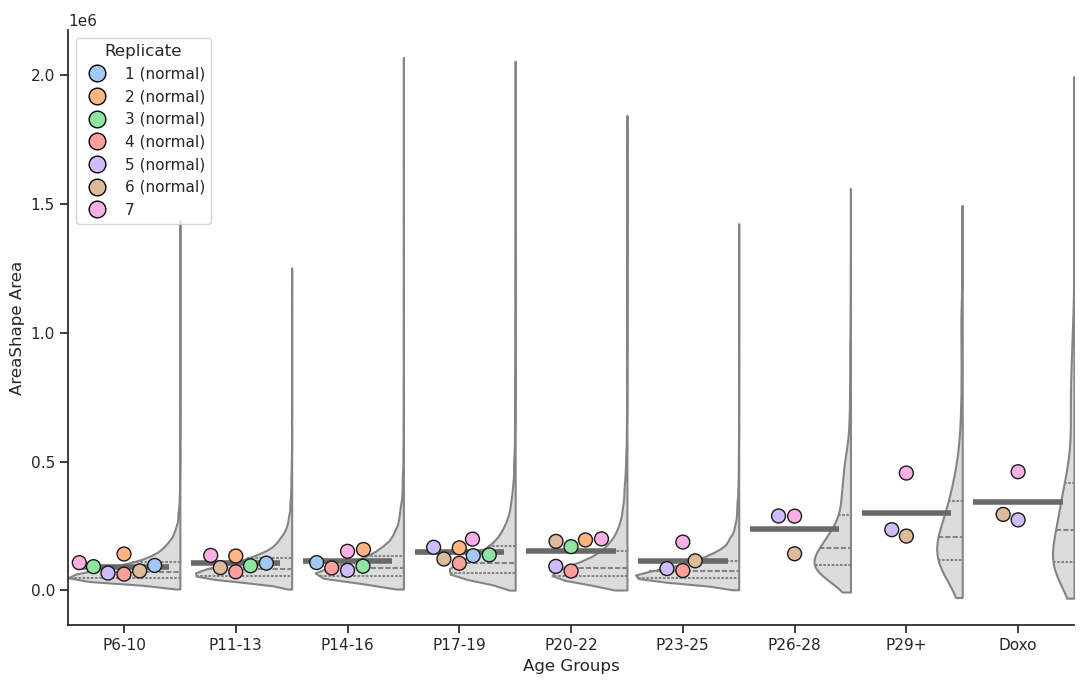

In [57]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None#"Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

this_df = combined_cell_df_mitolyso_merged.copy()
#this_df = norm_cell_df_mitolyso.copy()
data_df = this_df # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
#this_df = combined_cell_df_mitolyso_merged.copy()

# Map each replicate to a color and hard code that shit
colour_dict = get_hard_code_replicate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude=[]
plot_dir = "plots/notnorm" 
os.makedirs(plot_dir, exist_ok=True)

figsize = (11, 7)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    replicate_col_name="Replicate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="games",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,#True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=False,
    legend=True,
    context = "talk",
    figsize = figsize,
    pallete=pallete,
    p_correction="fdr_bh"
    #truncate_outliers=True
)

#NOTE: R5 has smallest cells in p23-25, which is also highest mito density 

## Make multiple plots as defined

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(



ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       36  9.197    0.000  0.671


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T    p-tukey    hedges
------  ------  ----------  ----------  -----------  ---------  ------  ---------  --------
Doxo    P11-13  225123.274   96045.823   129077.451  26588.867   4.855      0.001     3.855
Doxo    P14-16  225123.274  100635.577   124487.697  26588.867   4.682      0.001     3.295
Doxo    P17-19  225123.274  123613.403   101509.871  25948.077   3.912      0.010     3.018
Doxo    P20-22  225123.274  122118.023   103005.251  26588.867   3.874      0.011     2.328
Doxo    P23-25  225123.274  100666.264   124457.010  28719.258   4.334      0.003     2.682
Doxo    P26-28  225123.274  194808.706    30314.568  30702.179   0.987      0.985     0.424
Doxo    P29+    225123.274  238060.683   -12937.409  30702.179  -0.421      1

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


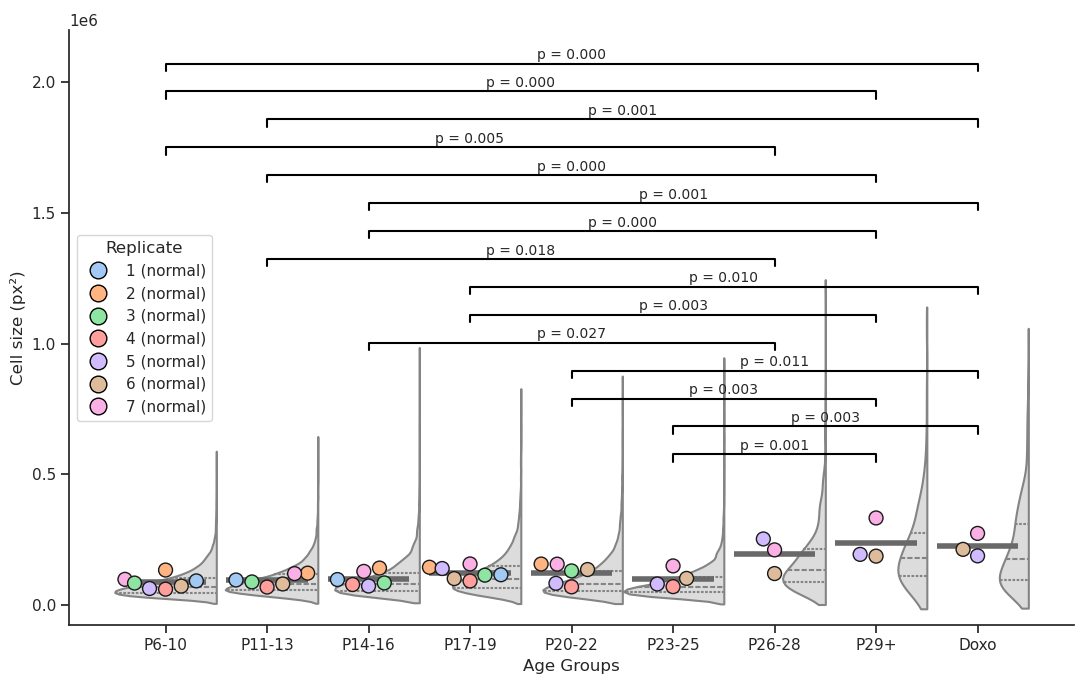

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(



POST HOC TESTS

A       B         mean(A)    mean(B)        diff        se       T    p-tukey    hedges
------  ------  ---------  ---------  ----------  --------  ------  ---------  --------
Doxo    P11-13  42698.045  22952.588   19745.457  3241.173   6.092      0.000     3.636
Doxo    P14-16  42698.045  23431.869   19266.176  3241.173   5.944      0.000     3.260
Doxo    P17-19  42698.045  26218.627   16479.418  3163.061   5.210      0.000     3.111
Doxo    P20-22  42698.045  25734.185   16963.860  3241.173   5.234      0.000     2.708
Doxo    P23-25  42698.045  24054.289   18643.756  3500.867   5.325      0.000     2.739
Doxo    P26-28  42698.045  34240.020    8458.025  3742.584   2.260      0.392     1.002
Doxo    P29+    42698.045  41553.146    1144.899  3742.584   0.306      1.000     0.112
Doxo    P6-10   42698.045  21704.224   20993.821  3163.061   6.637      0.000     3.830
P11-13  P14-16  22952.588  23431.869    -479.281  2646.407  -0.181      1.000    -0.126
P11-13  P17-19 

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


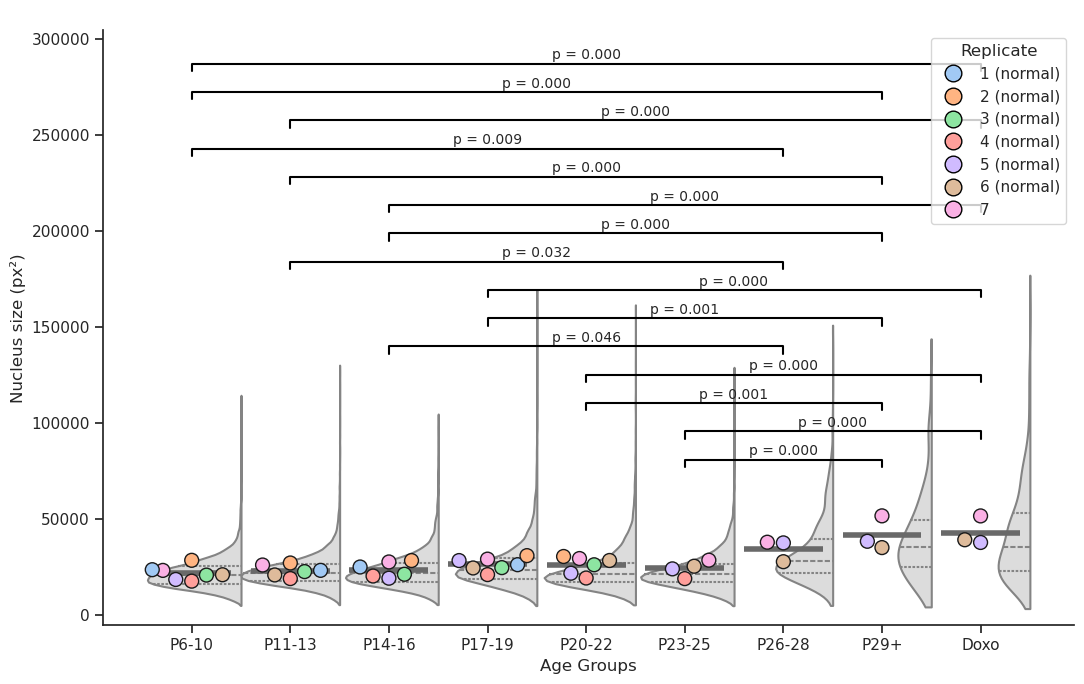

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(



POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P11-13      5.320      4.151   1.169  0.419   2.791      0.153     2.988
Doxo    P14-16      5.320      4.231   1.089  0.419   2.599      0.222     2.167
Doxo    P17-19      5.320      4.661   0.659  0.409   1.613      0.792     1.568
Doxo    P20-22      5.320      4.644   0.676  0.419   1.615      0.791     0.995
Doxo    P23-25      5.320      4.132   1.188  0.452   2.626      0.212     1.725
Doxo    P26-28      5.320      5.489  -0.169  0.484  -0.350      1.000    -0.176
Doxo    P29+        5.320      5.463  -0.143  0.484  -0.297      1.000    -0.187
Doxo    P6-10       5.320      3.921   1.399  0.409   3.423      0.037     2.958
P11-13  P14-16      4.151      4.231  -0.080  0.342  -0.235      1.000    -0.160
P11-13  P17-19      4.151      4.661  -0.510  0.330  -1.547      0.826    -1.139
P11-13  P20

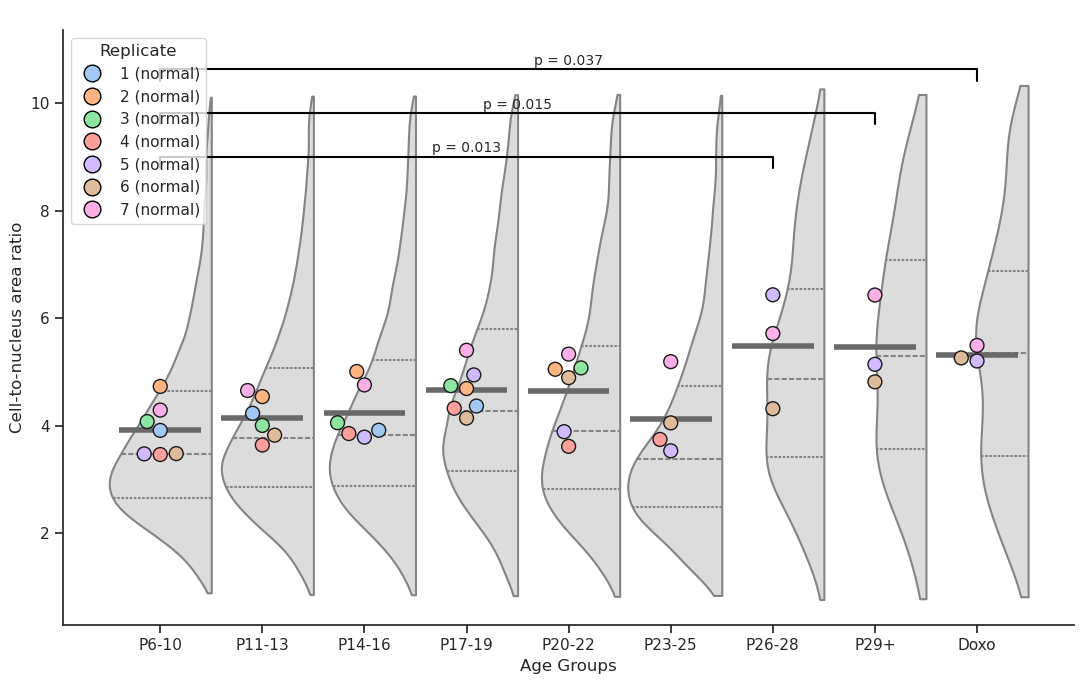

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this 

#a1c9f4


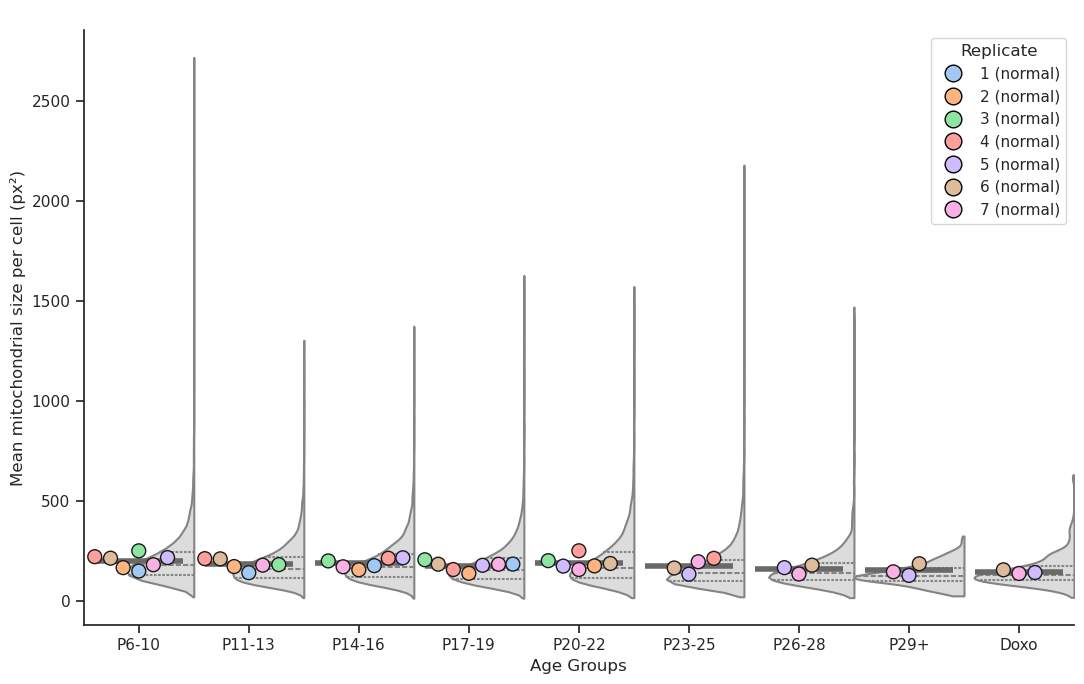

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want

#a1c9f4


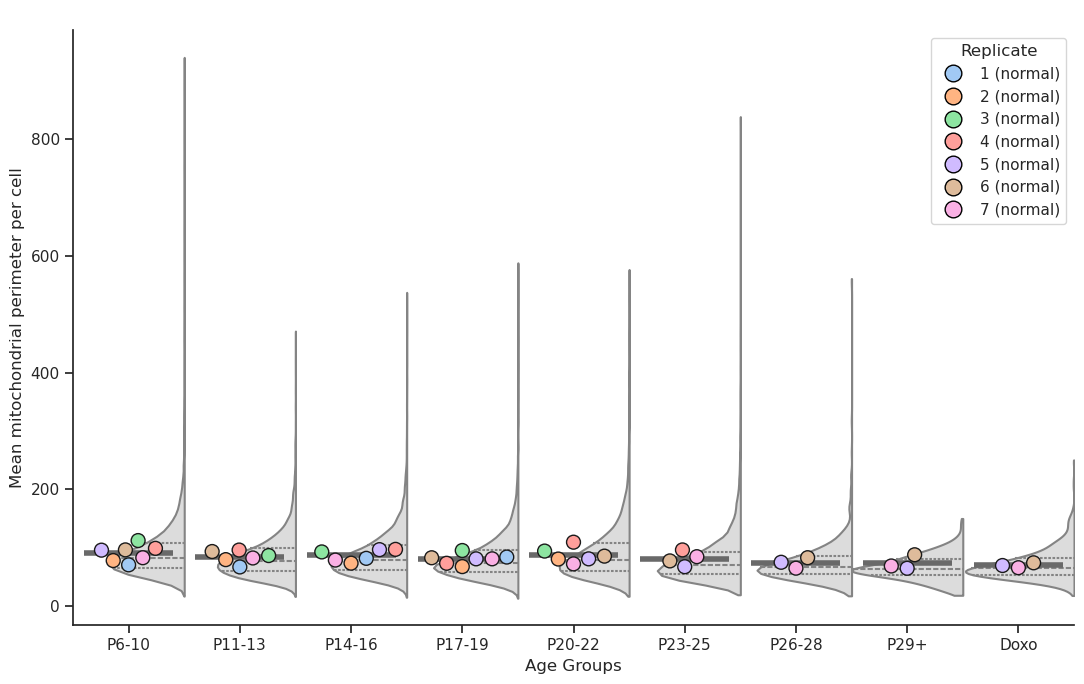

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


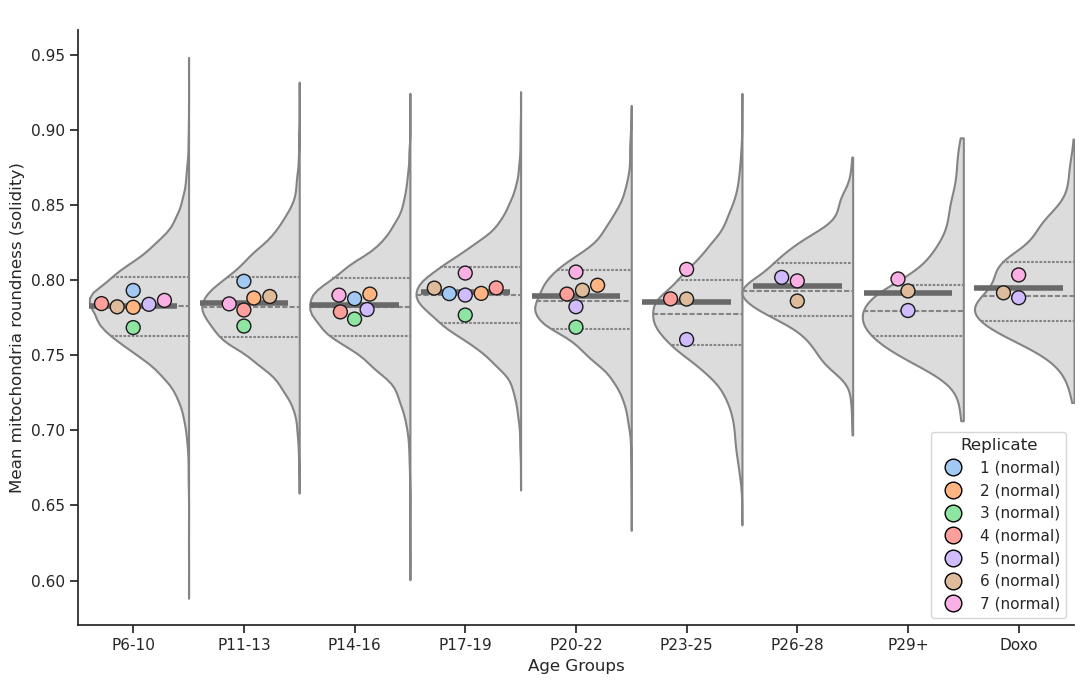

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


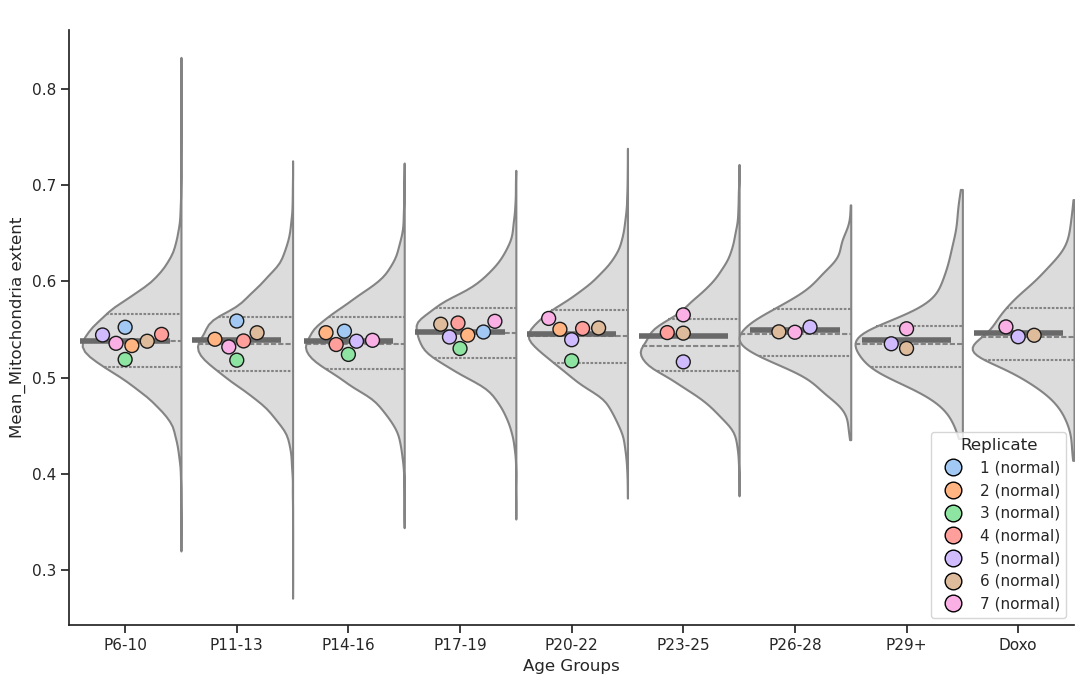

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want


POST HOC TESTS

A       B         mean(A)    mean(B)       diff       se       T    p-tukey    hedges
------  ------  ---------  ---------  ---------  -------  ------  ---------  --------
Doxo    P11-13    651.487   1182.790   -531.303  277.865  -1.912      0.610    -1.476
Doxo    P14-16    651.487   1246.759   -595.272  277.865  -2.142      0.462    -1.456
Doxo    P17-19    651.487   1077.594   -426.107  271.169  -1.571      0.813    -2.114
Doxo    P20-22    651.487   1145.095   -493.608  277.865  -1.776      0.696    -1.126
Doxo    P23-25    651.487   1173.249   -521.762  300.129  -1.738      0.720    -0.973
Doxo    P26-28    651.487   1064.278   -412.791  320.851  -1.287      0.929    -0.932
Doxo    P29+      651.487    447.670    203.817  320.851   0.635      0.999     1.488
Doxo    P6-10     651.487   1555.074   -903.587  271.169  -3.332      0.046    -2.231
P11-13  P14-16   1182.790   1246.759    -63.969  226.876  -0.282      1.000    -0.146
P11-13  P17-19   1182.790   1077.594 

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


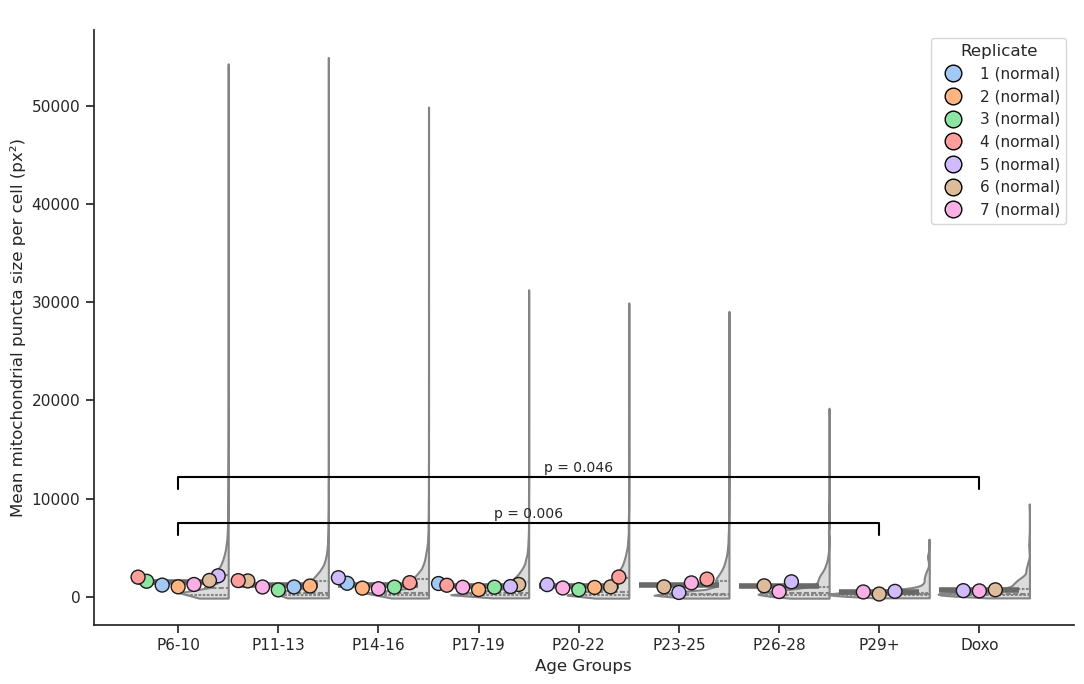

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want


POST HOC TESTS

A       B         mean(A)    mean(B)      diff      se       T    p-tukey    hedges
------  ------  ---------  ---------  --------  ------  ------  ---------  --------
Doxo    P11-13    116.051    178.819   -62.769  30.074  -2.087      0.497    -1.587
Doxo    P14-16    116.051    184.929   -68.878  30.074  -2.290      0.374    -1.655
Doxo    P17-19    116.051    164.561   -48.510  29.349  -1.653      0.770    -2.155
Doxo    P20-22    116.051    171.643   -55.592  30.074  -1.848      0.651    -1.206
Doxo    P23-25    116.051    173.825   -57.774  32.484  -1.779      0.695    -0.953
Doxo    P26-28    116.051    161.119   -45.068  34.727  -1.298      0.926    -0.908
Doxo    P29+      116.051     92.567    23.484  34.727   0.676      0.999     1.197
Doxo    P6-10     116.051    220.472  -104.421  29.349  -3.558      0.026    -2.413
P11-13  P14-16    178.819    184.929    -6.109  24.556  -0.249      1.000    -0.133
P11-13  P17-19    178.819    164.561    14.259  23.662   0.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


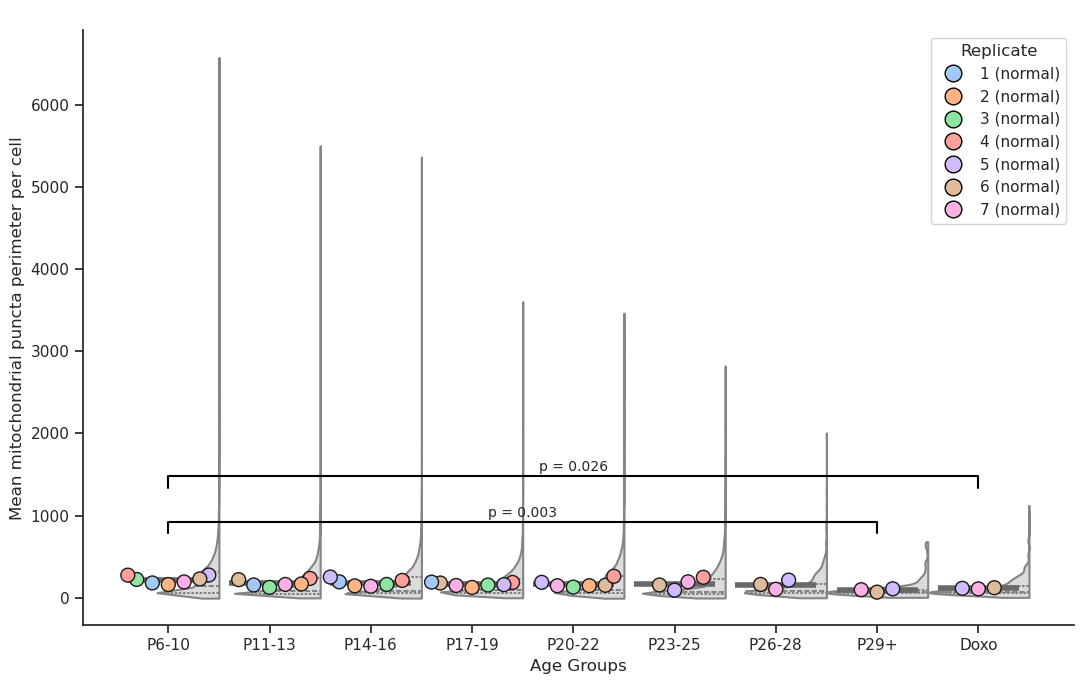

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this 

#a1c9f4


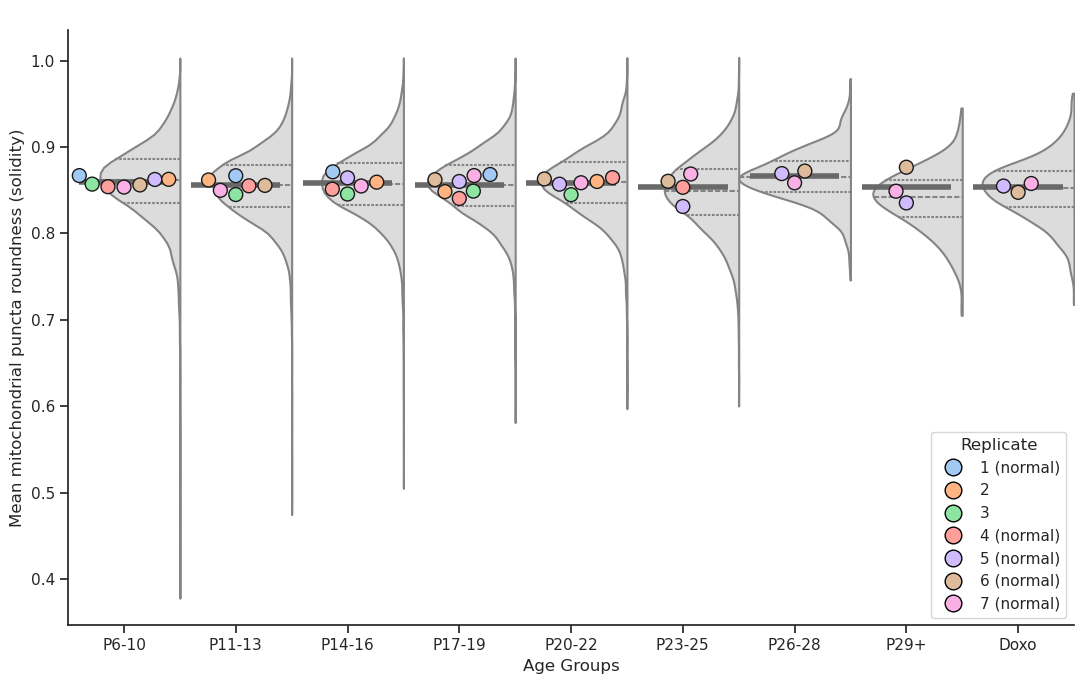

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want

#a1c9f4


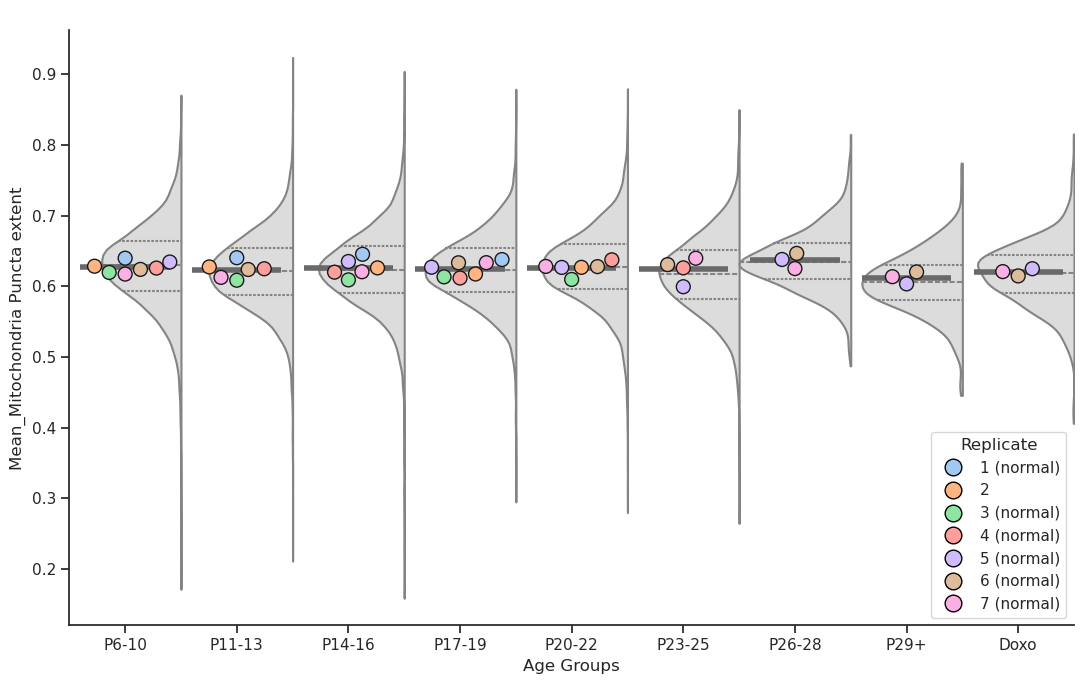

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


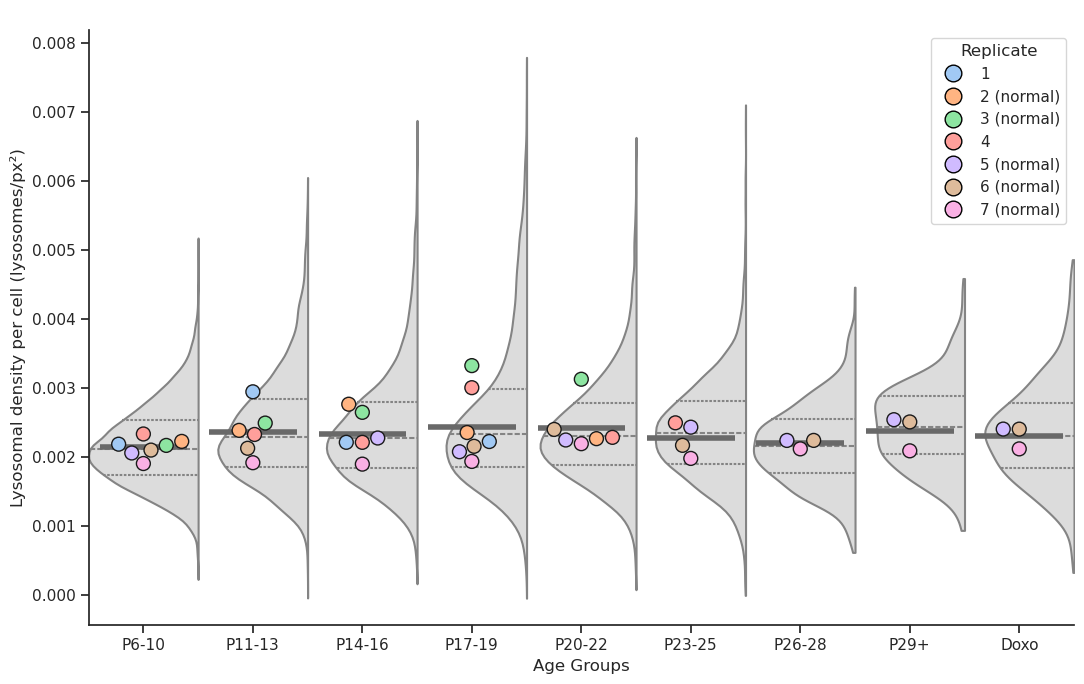

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


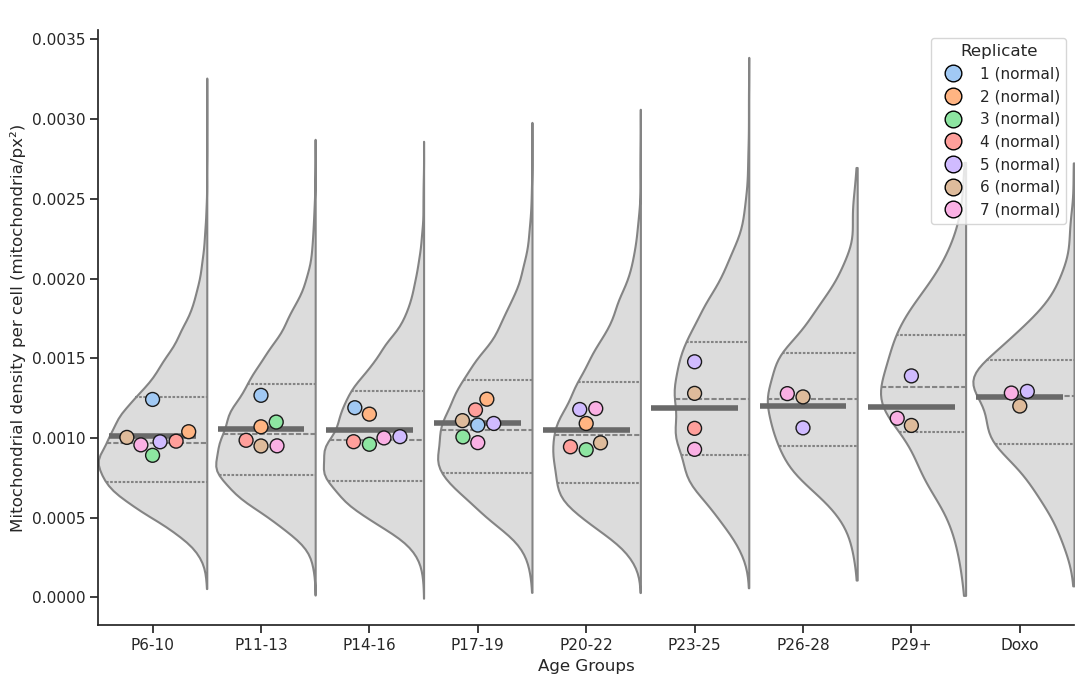

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(



ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       36  1.054    0.416  0.190

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.
#a1c9f4


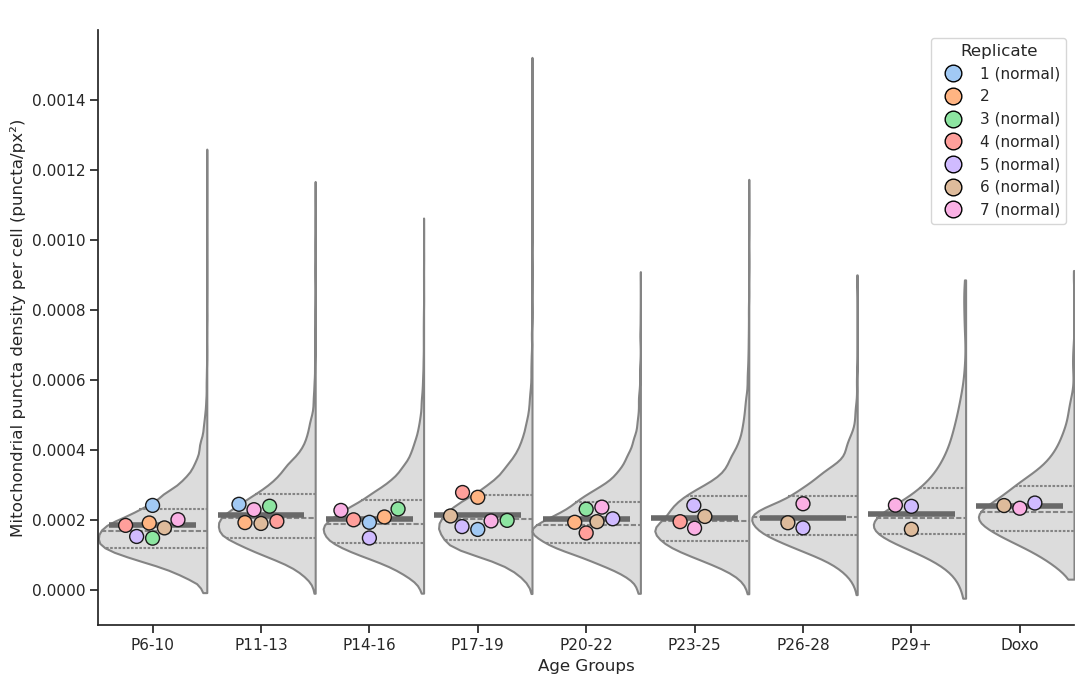

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


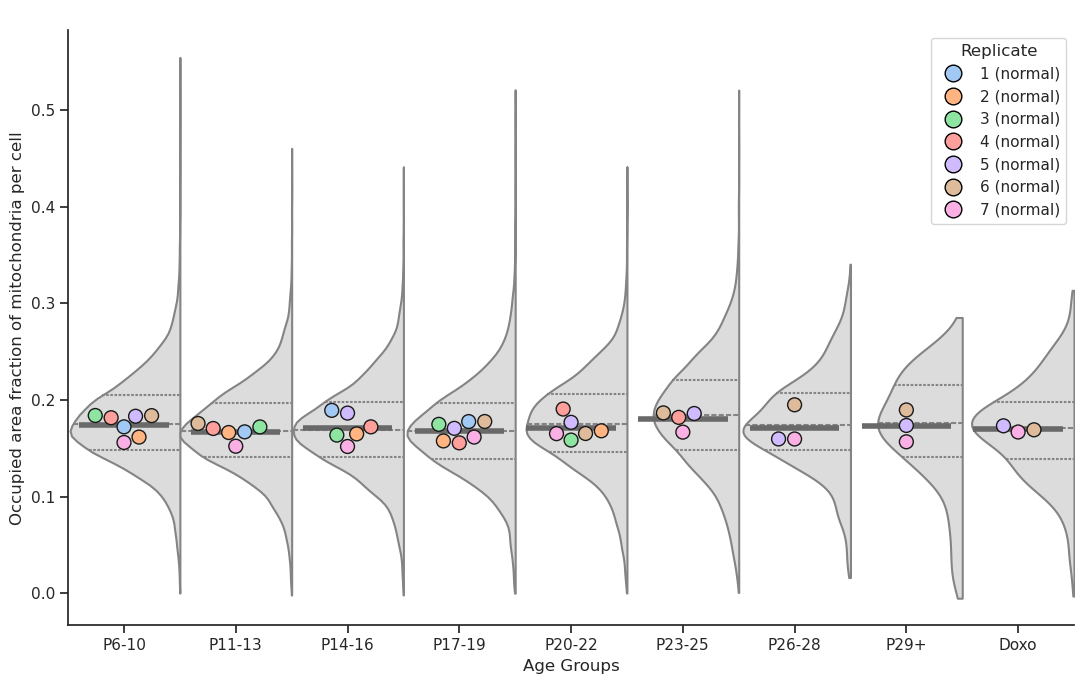

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


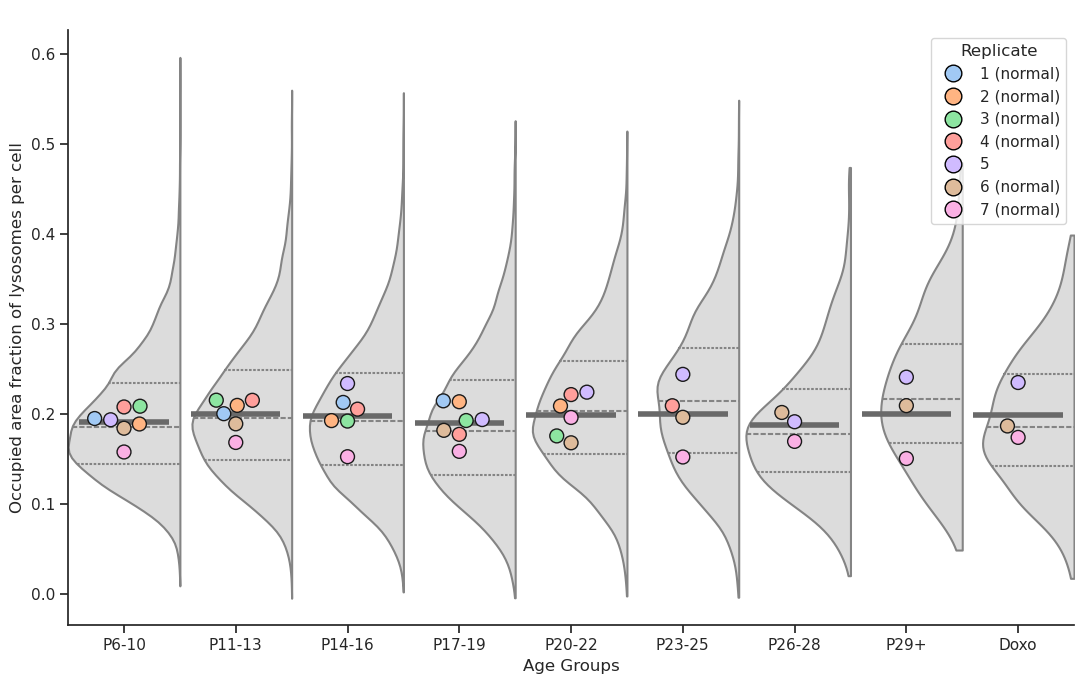

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


#a1c9f4


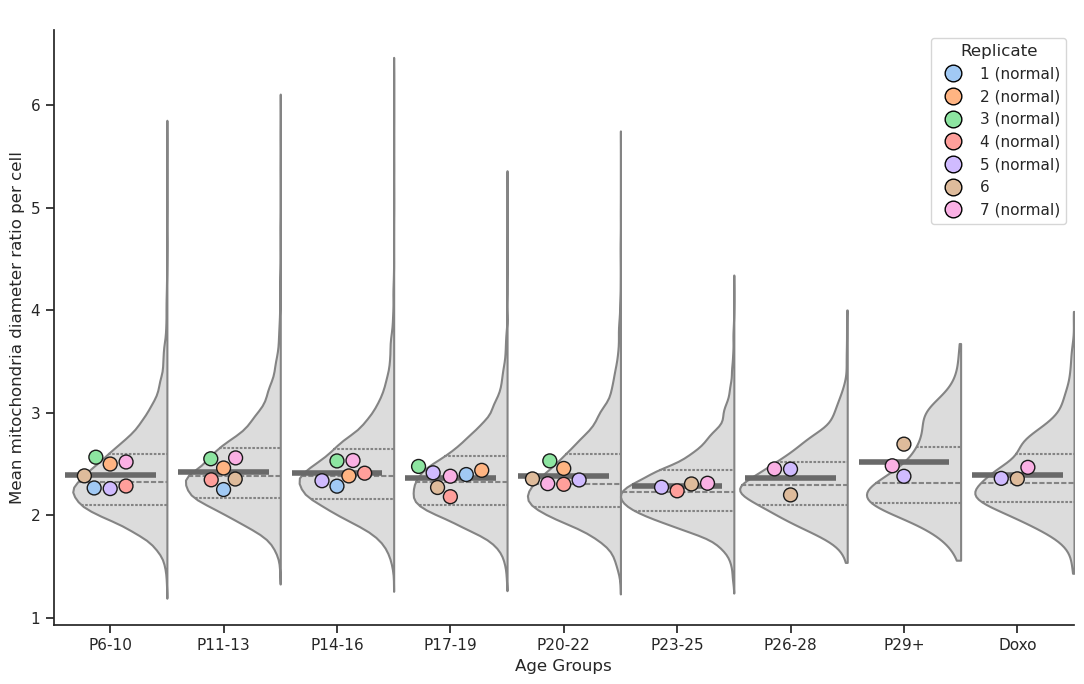

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


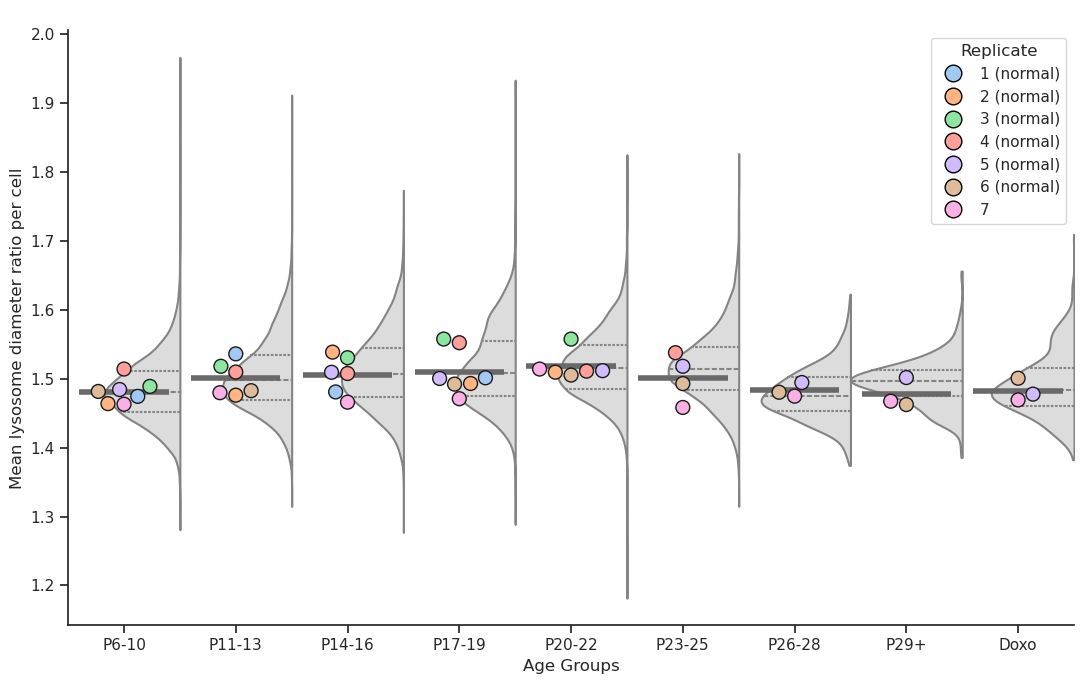

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(



POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P11-13      0.001      0.002  -0.000  0.000  -3.385      0.040    -2.753
Doxo    P14-16      0.001      0.002  -0.000  0.000  -3.273      0.053    -2.416
Doxo    P17-19      0.001      0.002  -0.000  0.000  -2.275      0.383    -2.378
Doxo    P20-22      0.001      0.002  -0.000  0.000  -2.568      0.236    -1.557
Doxo    P23-25      0.001      0.002  -0.000  0.000  -3.281      0.052    -2.418
Doxo    P26-28      0.001      0.001  -0.000  0.000  -0.584      1.000    -0.552
Doxo    P29+        0.001      0.001  -0.000  0.000  -0.705      0.998    -0.397
Doxo    P6-10       0.001      0.002  -0.001  0.000  -4.098      0.006    -2.787
P11-13  P14-16      0.002      0.002   0.000  0.000   0.137      1.000     0.078
P11-13  P17-19      0.002      0.002   0.000  0.000   1.481      0.857     0.988
P11-13  P20

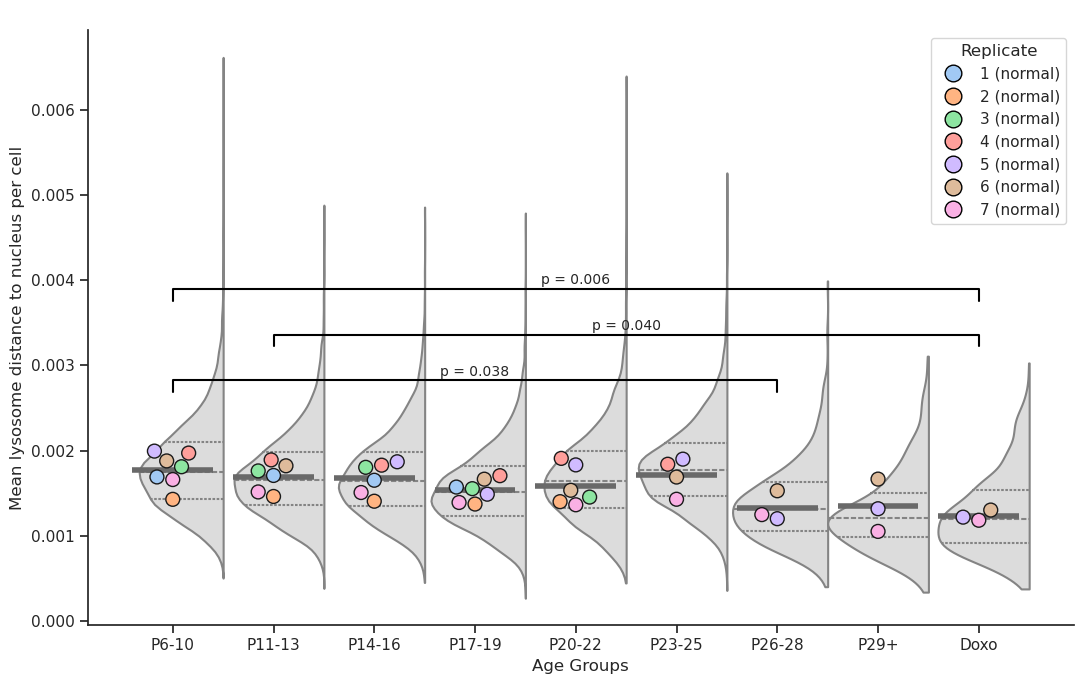

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want

#a1c9f4


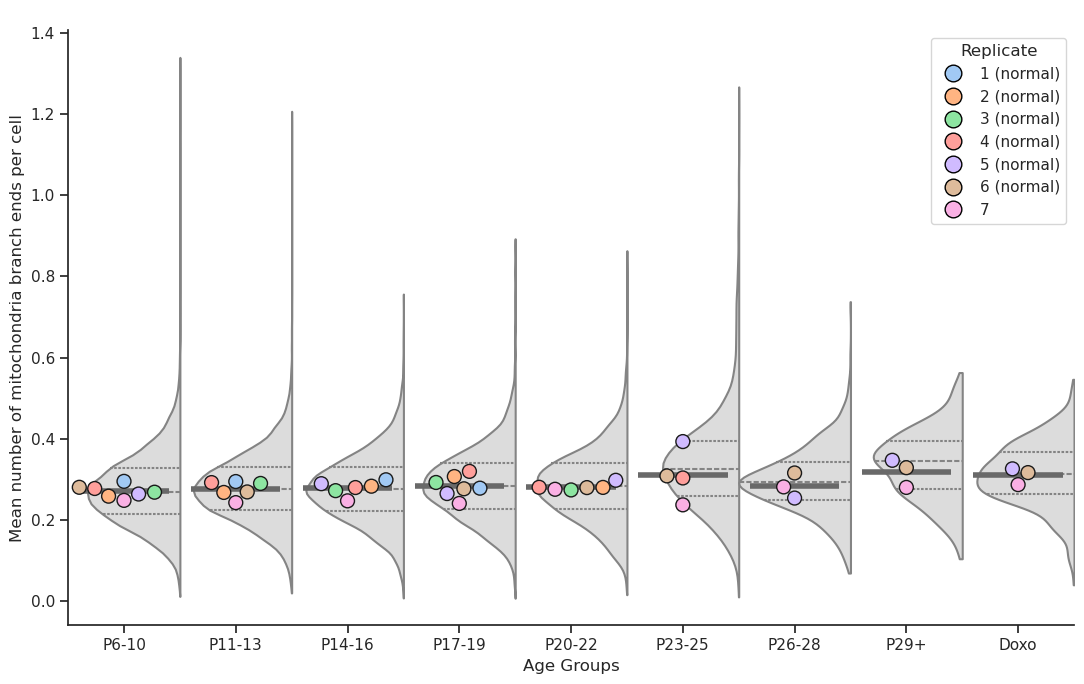

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


#a1c9f4


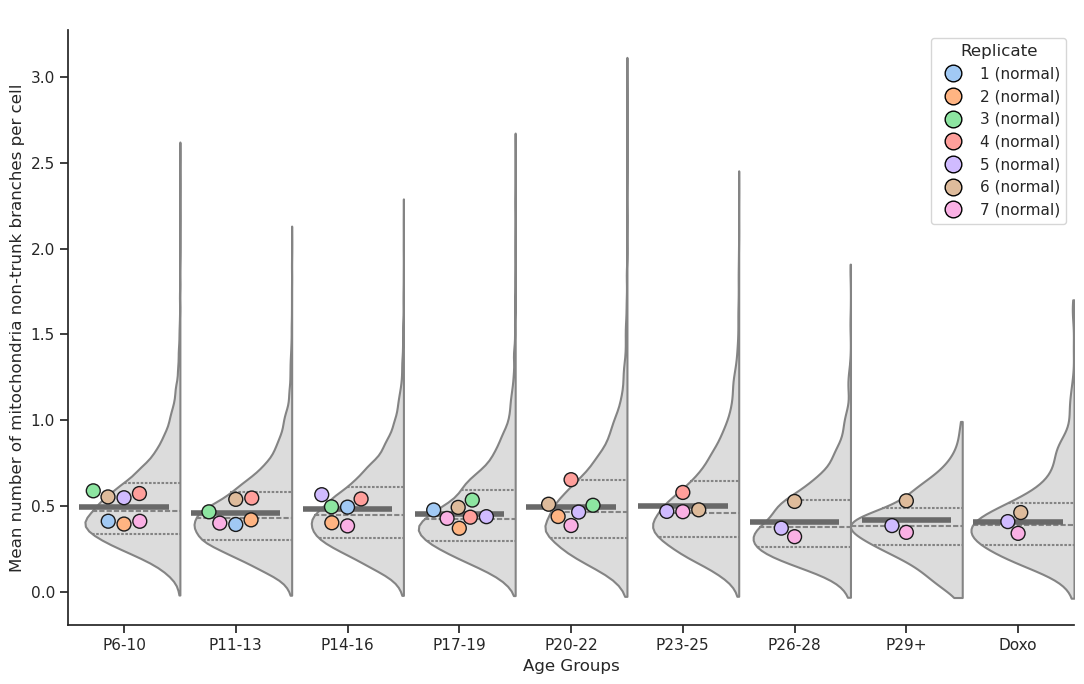

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want

#a1c9f4


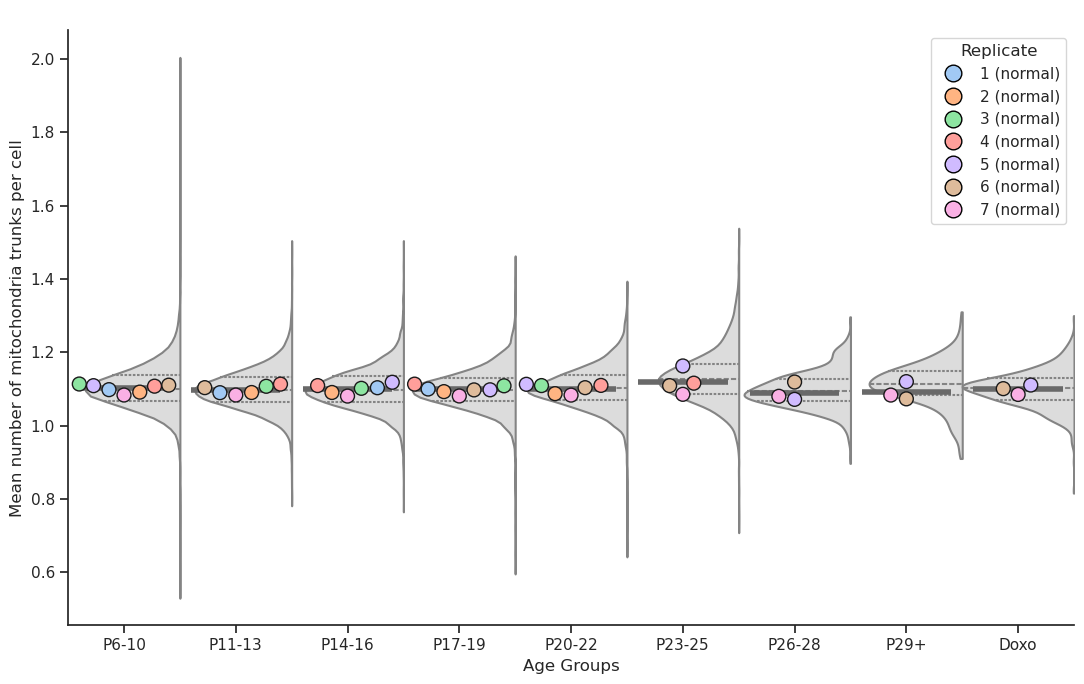

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


#a1c9f4


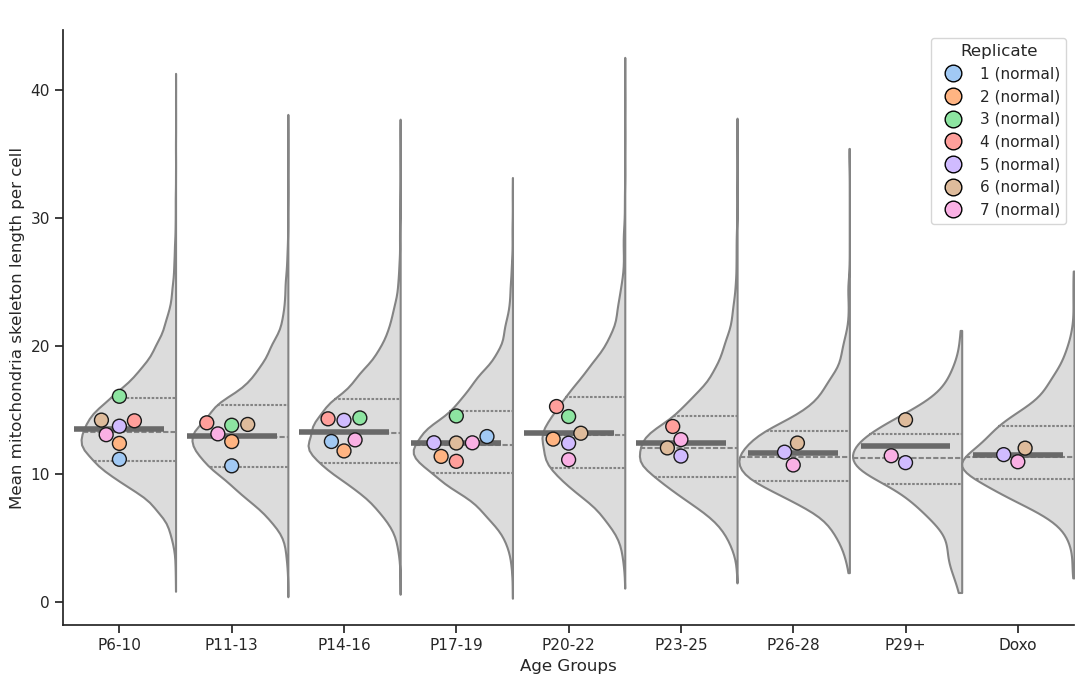

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want

#a1c9f4


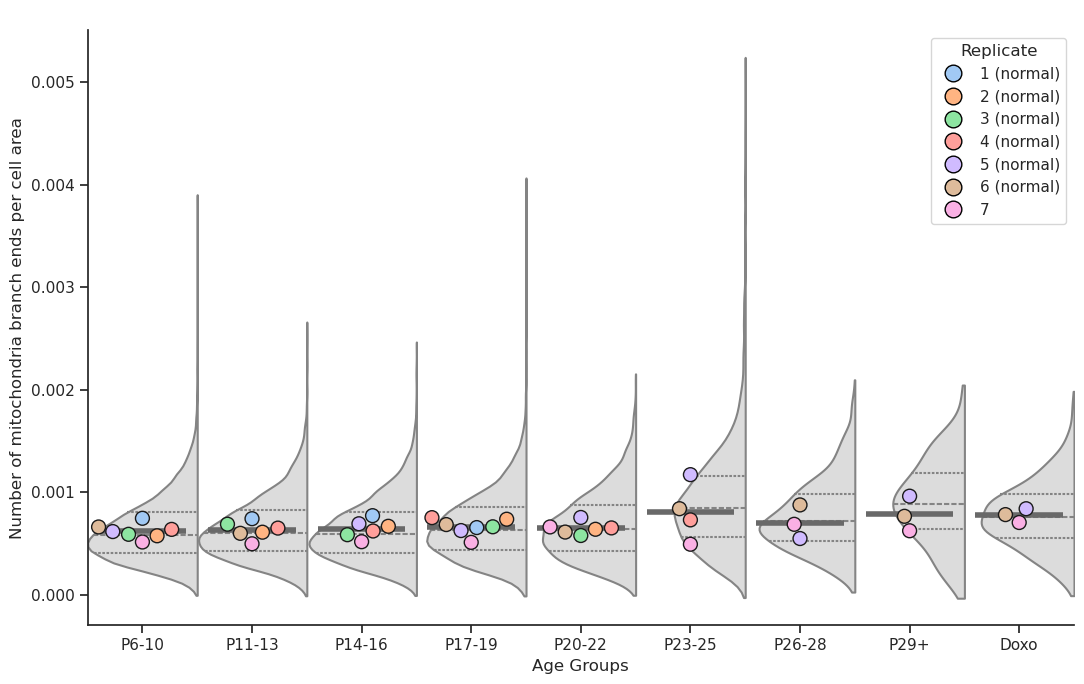

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


#a1c9f4


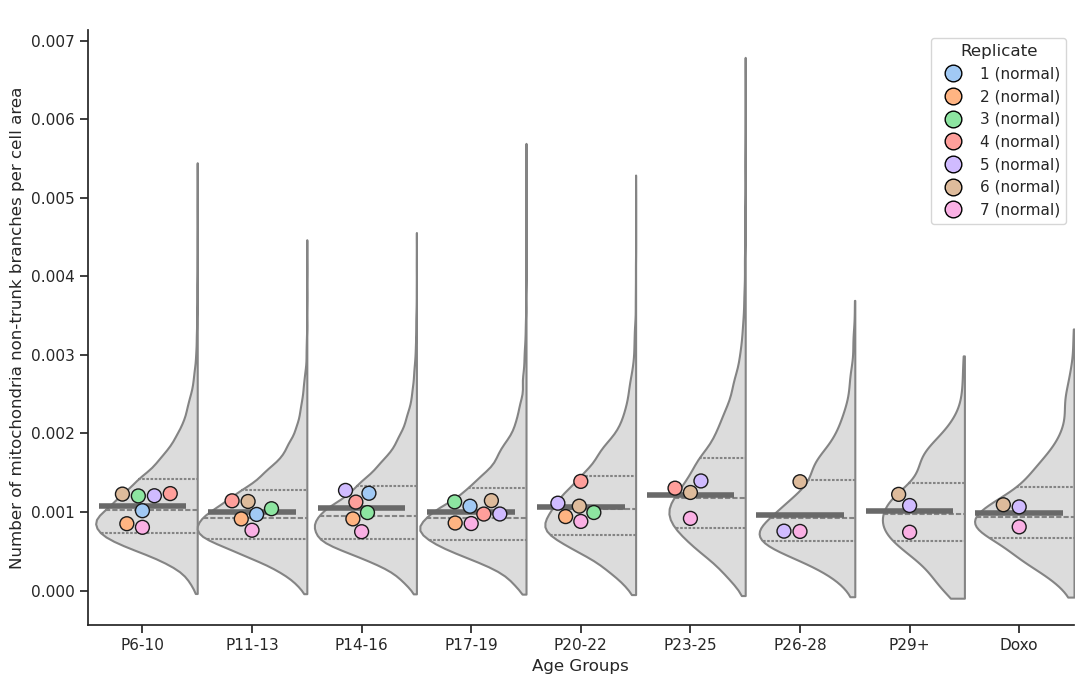

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


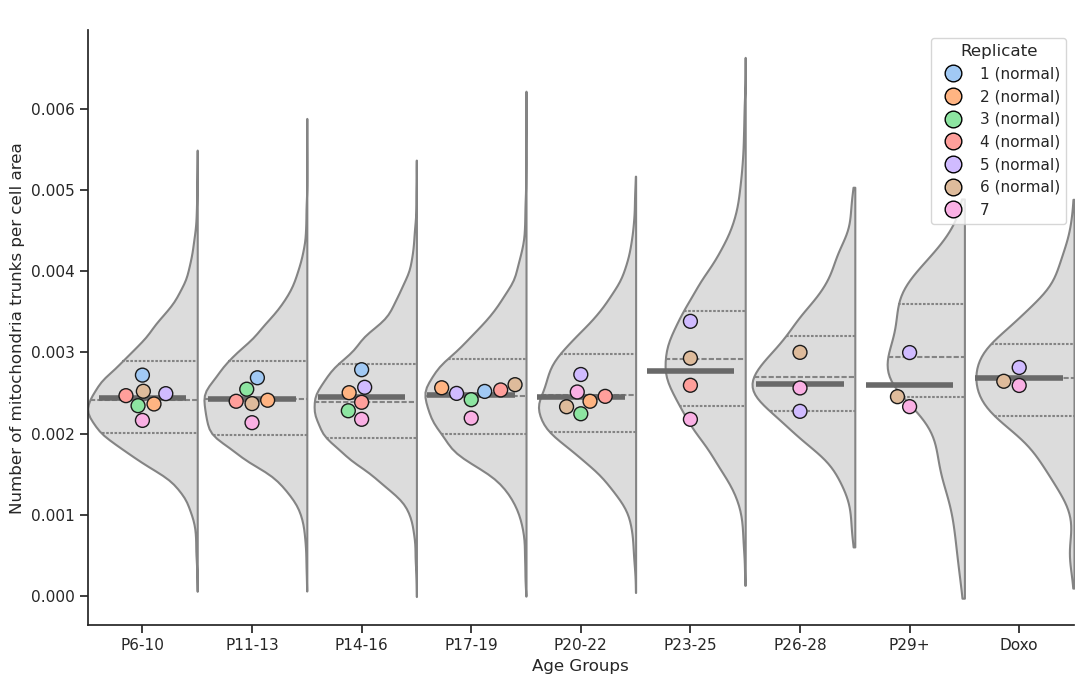

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:292: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_avg_df_pivot = group_avg_df.pivot_table(


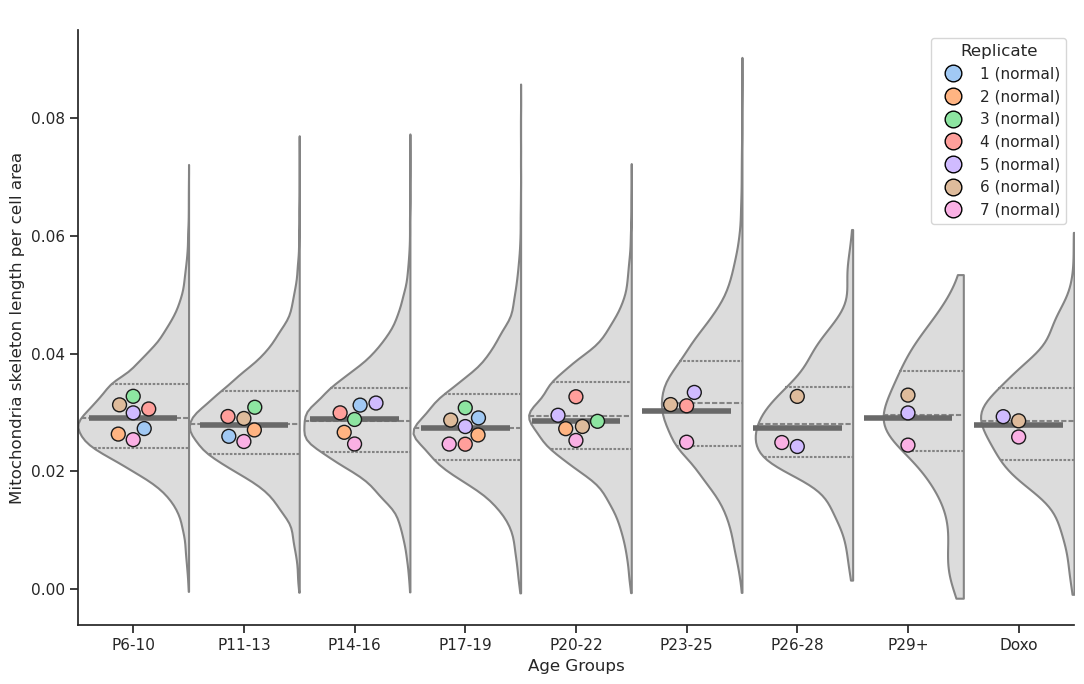

In [21]:
#prep these for the presentation
features_for_presentation = [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Mean_Mitochondria_AreaShape_Area",
    "Mean_Mitochondria_AreaShape_Perimeter",
    "Mean_Mitochondria_AreaShape_Solidity",
    "Mean_Mitochondria_AreaShape_Extent",
    "Mean_Mitochondria_Puncta_AreaShape_Area",
    "Mean_Mitochondria_Puncta_AreaShape_Perimeter",
    "Mean_Mitochondria_Puncta_AreaShape_Solidity",
    "Mean_Mitochondria_Puncta_AreaShape_Extent",
    # "Mean_Mitochondria_AreaShape_FormFactor",
    "Density_Children_Lysosomes_Count_PerCell_Area",
    "Density_Children_Mitochondria_Count_PerCell_Area",
    "Density_Children_Mitochondria_Puncta_Count_PerCell_Area",
    "OccupiedAreaFraction_Mitochondria_PerCell_Area",
    "OccupiedAreaFraction_Lysosomes_PerCell_Area",
    "Mean_Mitochondria_MaxMinFeret_DiameterRatio_PerCell",
    "Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell",
    "Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area",
    "Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton",
    "Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn",
    "Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton",
    "Mean_MitoEnds_ObjectSkeleton_TotalObjectSkeltnLngth_MtSkltn",
    "MitoEnds_NumberBranchEnds_PerCell_Area",
    "MitoEnds_NumberNonTrunkBranches_PerCell_Area",
    "MitoEnds_NumberTrunks_PerCell_Area",
    "MitoEnds_TotalObjectSkeltnLngth_PerCell_Area",
]
feature_names = [
    "Cell size (px\u00b2)",
    "Nucleus size (px\u00b2)",
    "Cell-to-nucleus area ratio",
    "Mean mitochondrial size per cell (px\u00b2)",
    "Mean mitochondrial perimeter per cell",
    "Mean mitochondria roundness (solidity)",
    "Mean_Mitochondria extent",
    "Mean mitochondrial puncta size per cell (px\u00b2)",
    "Mean mitochondrial puncta perimeter per cell",
    "Mean mitochondrial puncta roundness (solidity)",
    "Mean_Mitochondria Puncta extent",
    # "Mean_Mitochondria_AreaShape_FormFactor",
    "Lysosomal density per cell (lysosomes/px\u00b2)",
    "Mitochondrial density per cell (mitochondria/px\u00b2)",
    "Mitochondrial puncta density per cell (puncta/px\u00b2)",
    "Occupied area fraction of mitochondria per cell",
    "Occupied area fraction of lysosomes per cell",
    "Mean mitochondria diameter ratio per cell",
    "Mean lysosome diameter ratio per cell",
    "Mean lysosome distance to nucleus per cell",
    "Mean number of mitochondria branch ends per cell",
    "Mean number of mitochondria non-trunk branches per cell",
    "Mean number of mitochondria trunks per cell",
    "Mean mitochondria skeleton length per cell",
    "Number of mitochondria branch ends per cell area",
    "Number of mitochondria non-trunk branches per cell area",
    "Number of mitochondria trunks per cell area",
    "Mitochondria skeleton length per cell area",
]

norm = False
if norm:
    data_df = norm_cell_df_mitolyso.copy()
else:
    this_df = combined_cell_df_mitolyso_merged.copy()
    data_df = this_df[this_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
    
colour_dict = get_hard_code_replicate_colours(data_df)
pallete = colour_dict  # "pastel"

pallete = colour_dict
remove_outliers = False
reps_to_exclude=[]
plot_dir = "plots/notnorm" 
os.makedirs(plot_dir, exist_ok=True)
figsize = (11, 7)
truncate_outliers=False
rm_outliers_method = "gesd_2"
test="tukey_v3"
pairs = getpairs(combined_cell_df_mitolyso, group, order)

for i,feature in enumerate(features_for_presentation):
    order = get_all_group_order()
    
    ylabel = feature_names[i]
    xlabel = "Age Groups"
    group = "AllGroups"
    
    single_feature_super_splitviolinplot(
        data_df,
        x_value=group,
        y_value=feature,
        replicate_col_name="Replicate_Number",
        xtitle=xlabel,
        ytitle=ylabel,
        out_dir=plot_dir,
        annotate=True,
        order=order,
        test=test,
        reps_to_exclude=reps_to_exclude,
        show_hist=False,  # True,
        remove_outliers=remove_outliers,
        rm_outliers_method=rm_outliers_method,
        truncate_outliers=False,
        legend=True,
        context="talk",
        figsize=figsize,
        pallete=pallete,
        p_correction="fdr_bh",
        # truncate_outliers=True
    )
#Make the one without annoations
    # single_feature_super_splitviolinplot(
    #     data_df,
    #     x_value=group,
    #     y_value=feature,
    #     replicate_col_name="Replicate_Number",
    #     xtitle=xlabel,
    #     ytitle=ylabel,
    #     out_dir=plot_dir,
    #     annotate=False,
    #     order=order,
    #     test="None",
    #     reps_to_exclude=reps_to_exclude,
    #     show_hist=False,
    #     remove_outliers=remove_outliers,
    #     rm_outliers_method=rm_outliers_method,
    #     legend=False,
    #     context="talk",
    #     figsize=figsize,
    #     truncate_outliers=True,
    #     norm=norm,
    # )


In [22]:
def make_a_shitton_of_plots(
    order = [],
    xlabel = "Age Groups",
    group = "AllGroups",
    pairs = getpairs(combined_cell_df_mitolyso, group, order),
    pallete = "pastel",
    remove_outliers = False,
    truncate_outliers = False,
    reps_to_exclude=[],
    norm = False
):
    if not order:
        order = get_all_group_order()
        
        
        
        
        
        
        
    if norm:
        this_df = norm_cell_df_mitolyso.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/norm"
        )
    else:
        this_df = combined_cell_df_mitolyso_merged.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/notnorm"
        )
    os.makedirs(big_out_folder, exist_ok=True)
    #iterate and make big ball of plots
    for compartment, feature_dict in zip(feature_names, feature_dicts):
        feature_folder = Path(big_out_folder, compartment)
        Path.mkdir(feature_folder, exist_ok=True)
        for feature_type, features in feature_dict.items():
            newfolder = Path(feature_folder,feature_type)
            Path.mkdir(newfolder, exist_ok=True)
            for feature in features:
                single_feature_super_splitviolinplot(
                    this_df,
                    x_value=group,
                    y_value=feature,
                    replicate_col_name="Replicate_Number",
                    xtitle=xlabel,
                    ytitle=None,
                    out_dir=newfolder,
                    annotate=True,
                    order=order,
                    test="conover",
                    reps_to_exclude=reps_to_exclude,
                    show_hist=False,
                    remove_outliers=remove_outliers,
                    #truncate_outliers=truncate_outliers,
                    show=False,
                    legend=True,
                    context = "talk",
                    figsize = (12,8)
                )
# make_a_shitton_of_plots(reps_to_exclude=[],norm=False)
# make_a_shitton_of_plots(reps_to_exclude=[], norm=True)

## Attempting PCA

In [23]:
vars = mito_features["areashape"]
    

In [24]:

from sklearn.decomposition import PCA
n_components = 2
pca = PCA(n_components)

x_df = this_df[vars.__add__
    (["AllGroups",
    "Replicate_Number","AreaShape_Area"])].dropna()
display(x_df)
components = pca.fit_transform(x_df[vars])
display(components)

fig = px.scatter(components, x=0, y=1, color=x_df["AllGroups"],symbol=x_df["Replicate_Number"])
total_var = pca.explained_variance_ratio_.sum() * 100

# labels = {str(i): f"PC {i + 1}" for i in range(n_components)}
# labels["color"] = "AllGroups"

# fig = px.scatter_matrix(
#     components,
#     color=x_df["AllGroups"],
#     dimensions=range(n_components),
#     labels=labels,
#     title=f"Total Explained Variance: {total_var:.2f}%",
# )
# fig.update_traces(diagonal_visible=False)
fig.show()

# labels = {
#     str(i): f"PC {i + 1} ({var:.1f}%)"
#     for i, var in enumerate(pca.explained_variance_ratio_ * 100)
# }

# fig = px.scatter_matrix(
#     components, labels=labels, dimensions=range(4), color=df["species"]
# )
# fig.update_traces(diagonal_visible=False)
# fig.show()


,Mean_Mitochondria_AreaShape_Area,Mean_Mitochondria_AreaShape_BoundingBoxArea,Mean_Mitochondria_AreaShape_BoundingBoxMaximum_X,Mean_Mitochondria_AreaShape_BoundingBoxMaximum_Y,Mean_Mitochondria_AreaShape_BoundingBoxMinimum_X,Mean_Mitochondria_AreaShape_BoundingBoxMinimum_Y,Mean_Mitochondria_AreaShape_Center_X,Mean_Mitochondria_AreaShape_Center_Y,Mean_Mitochondria_AreaShape_Compactness,Mean_Mitochondria_AreaShape_ConvexArea,...,Median_Mitochondria_AreaShape_MeanRadius,Median_Mitochondria_AreaShape_MedianRadius,Median_Mitochondria_AreaShape_MinFeretDiameter,Median_Mitochondria_AreaShape_MinorAxisLength,Median_Mitochondria_AreaShape_Orientation,Median_Mitochondria_AreaShape_Perimeter,Median_Mitochondria_AreaShape_Solidity,AllGroups,Replicate_Number,AreaShape_Area
1,245.525641,904.884615,733.487179,1884.012821,712.807692,1867.820513,722.505066,1875.460647,3.495841,595.923077,...,1.678979,1.414214,6.912602,7.246360,45.160046,30.970563,0.897428,Doxo,6,116904.0
3,150.227891,463.996599,144.799320,1348.935374,132.625850,1326.469388,138.198697,1337.141476,2.476946,253.231293,...,1.647078,1.414214,6.612832,7.055674,-12.498215,38.142136,0.860522,Doxo,6,241819.0
5,116.132867,364.118881,220.496503,325.769231,203.251748,311.412587,211.526905,317.974711,2.569333,215.328671,...,1.508167,1.414214,6.000000,6.598540,0.732504,34.142136,0.788462,Doxo,6,95696.0
6,299.051546,1030.567010,1670.381443,1889.855670,1652.350515,1868.350515,1660.856676,1878.195022,4.891482,678.628866,...,1.653574,1.414214,6.658726,6.817467,19.604884,38.177670,0.838710,Doxo,6,114448.0
7,74.617647,170.764706,1712.029412,1425.264706,1703.137255,1409.323529,1707.103268,1416.993866,1.850854,105.460784,...,1.441880,1.000000,4.995131,5.331507,2.953768,28.295942,0.866795,Doxo,6,59796.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74415,54.979167,127.291667,329.729167,1646.479167,319.729167,1636.104167,324.192539,1640.828650,1.574521,76.270833,...,1.353101,1.000000,4.619319,5.173896,11.327617,23.156854,0.827778,P6-10,1,38208.0
74416,107.285714,276.673469,93.265306,1673.367347,79.836735,1658.265306,86.059134,1665.456647,2.481669,181.591837,...,1.422169,1.000000,6.516946,6.648167,-16.352736,36.970563,0.794521,P6-10,1,39024.0
74417,93.571429,252.207792,410.701299,1799.350649,400.064935,1782.688312,404.822186,1790.460583,2.243853,157.792208,...,1.418217,1.000000,5.209459,5.761562,5.555602,28.935029,0.824561,P6-10,1,47936.0
74418,53.611111,143.333333,1366.666667,571.055556,1356.611111,559.481481,1361.183703,564.821161,1.794572,85.925926,...,1.266626,1.000000,4.916074,5.012035,-20.879598,23.088835,0.781674,P6-10,1,63532.0


array([[  736.94575864,  2221.93309796],
       [-3032.93955691,   656.53343546],
       [-4168.41060261, -2198.44992133],
       ...,
       [ 8515.71241048,  1962.59119394],
       [-3157.12931521, -1404.09981385],
       [ 4356.41763926,    80.02054392]])

In [25]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(x_df[vars])
reducer = UMAP(random_state=42)
reducer.fit(scaled_data)

embedding = reducer.transform(scaled_data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert np.all(embedding == reducer.embedding_)
print(embedding.shape)

import sklearn.cluster as cluster

import sklearn.metrics as metrics

kmeans_labels = cluster.KMeans(n_clusters=9).fit_predict(scaled_data)

"""
From https://umap-learn.readthedocs.io/en/latest/clustering.html: 
The next thing to be aware of is that when using UMAP for dimension reduction you will want to select different parameters 
than if you were using it for visualization. First of all we will want a larger n_neighbors value 
small values will focus more on very local structure and are more prone to producing fine grained cluster structure 
that may be more a result of patterns of noise in the data than actual clusters. 
In this case well double it from the default 15 up to 30. Second it is beneficial to set min_dist to a very low value. 
Since we actually want to pack points together densely (density is what we want after all) a low value will help,
as well as making cleaner separations between clusters.
In this case we will simply set min_dist to be 0.
"""
clusterable_embedding = UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=42,
).fit_transform(scaled_data)

#now plot the embeddings
fig = px.scatter(
    embedding,
    x=0,
    y=1,
    color=kmeans_labels,#x_df["Replicate_Number"],
    symbol=x_df["AllGroups"],
    size=x_df["AreaShape_Area"]
    #labels={"color": kmeans_labels},
)
fig.show()


labels = cluster.HDBSCAN(
    min_samples=10,
    min_cluster_size=500,
).fit_predict(clusterable_embedding)

fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=labels,
    symbol=x_df["AllGroups"],  # x_df["Replicate_Number"],
    size=x_df["AreaShape_Area"],
    labels={"symbol" :x_df["AllGroups"]}#{"color": labels, }
)
fig.update_legends()
fig.show()




/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



(70037, 2)


/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



TypeError: unhashable type: 'Series'

In [ ]:
#Using one-way anova and Tukey's HSD to compare means of non normalized values
order = get_all_group_order()
feature_meas = "AreaShape_Area"
ylabel = "Area"


group = 'AllGroups'
replicates = 'Replicate_Number'
pairs = getpairs(combined_cell_df_mitolyso, group, order)
this_df = combined_cell_df_mitolyso_merged.copy()
pallete = "pastel"
remove_outliers = True

feature_df = make_single_feature_df(this_df, group=group, feature=feature_meas, replicates='Replicate_Number')
group_avg_df = average_groups_by_plate(feature_df, x_value=group, y_value=feature_meas, replicates='Replicate_Number')
group_avg_df_pivot = average_groups_pivot(group_avg_df, x_value=group, y_value=feature_meas, replicate_col_name='Replicate_Number')

if remove_outliers is True:
    feature_df = remove_outliers_iqr(feature_df)
    display(feature_df)

display(feature_df)
display(group_avg_df)
display(group_avg_df_pivot)

sns.set_theme(style="ticks")
#sns.set_context("notebook", font_scale=1.9)

plt.figure(figsize=(12, 8))
sns.set_context("talk", font_scale=0.5)
plt.figure(dpi=300)


sns.violinplot(data=feature_df, x=group,
            y=feature_meas,
            order=order,
            fill = False,
            color= 'gainsboro',
            cut=1,
            native_scale=True,
            linecolor='k',
            inner= None,
            #inner_kws=dict(box_width = 5)
            )

ax = sns.swarmplot(data=group_avg_df, x=group,
            y=feature_meas,
            hue = replicates,
            order=order,
            palette=pallete,
            size=10, 
            edgecolor="k", 
            linewidth=1,
            dodge=0.5)

#use a boxplot to draw the mean line - thinking outside the box :)
sns.boxplot(data = group_avg_df, x = group,
            y = feature_meas,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'dimgray', 'ls': '-', 'lw': 2.5},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax = ax)

ax.legend_.remove()

sns.despine()
plt.gcf()#.set_size_inches(10, 6)
plt.xlabel(group)
if ylabel == None:
    plt.ylabel(feature_meas.replace('_', ' '))


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

# Extract the data for each group

# Perform the one-way ANOVA test

# Print the results

pvalues,pairs = anova_with_tukey_posthoc(
    group_avg_df, x_value=group, y_value=feature_meas, display_results=True
)


annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order)
annotator.configure(text_format='star', loc='inside', verbose = 2, hide_non_significant=True)
annotator.set_pvalues_and_annotate(pvalues)

plt.savefig("plots/new_plots/" + feature_meas + '_anova_superviolinplot.png', dpi=300)
plt.show()



## Summary Stats

In [ ]:
summary_outpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/postprocessed_summary_stats/"
os.makedirs(summary_outpath, exist_ok=True)
feature_name = "AreaShape_Area"
feature_shortname = "Area"
include_cols = [
    "Number_Object_Number",
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
    "Children_Mitochondria_Puncta_Count",
]

def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag="original",
    replicate_col_name="Replicate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols=[],
):
    from pathlib import Path

    try:
        table_csvname = f"{df_tag}_total_combined_{feature_name}_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath, subfolder_name)
        parent_folder.mkdir(exist_ok=True)

        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe().to_csv(
            os.path.join(summary_outpath, subfolder_name, table_csvname)
        )
        group_averages = df.groupby(
            [x_value, replicate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        # average_df = group_averages.reset_index()
        avg_summary = group_averages.describe()
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, feature_csvname)
        )

        # do the agg by passage group only
        group_averages_agg = df.groupby([x_value], as_index=False, observed=True)[
            feature
        ]
        avg_agg_summary = group_averages_agg.describe()
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        )
        avg_agg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(
            f"saved files {(table_csvname, feature_csvname, agg_feature_csvname)} to {summary_outpath}"
        )
        return True
    except ValueError as e:
        print(f"Could not make summary stats: {e}")
        return False


this_df=combined_cell_df_mitolyso_merged.copy()
this_df_borders_excluded = combined_cell_df_mitolyso_borders_excluded.copy()
filtered_borders_excluded = apply_all_filters(
    this_df_borders_excluded
)

for feature in [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
]:
    make_summary_stats_for_df_and_feature(
        this_df,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols
    )
    make_summary_stats_for_df_and_feature(
        filtered_borders_excluded,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="borders_excluded",
        feature_name=feature,
        include_cols=include_cols,
    )
    


OG df: (52341, 3445), Filtered df: (52341, 3445), removing empty organelles: (52305, 3447), more than one cell: (51864, 3447), nuc size thresholded: (51798, 3447), cell:nuclei ratio filter: (50076, 3447)
saved files ('original_total_combined_AreaShape_Area_stats.csv', 'original_AreaShape_Area_by_passage_group_stats.csv', 'original_agg_AreaShape_Area_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/postprocessed_summary_stats/
saved files ('borders_excluded_total_combined_AreaShape_Area_stats.csv', 'borders_excluded_AreaShape_Area_by_passage_group_stats.csv', 'borders_excluded_agg_AreaShape_Area_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/postprocessed_summary_stats/
saved files ('original_total_combined_Nuclei_AreaShape_Area_stats.csv', 'original_Nuclei_AreaShape_Area_by_passage_group_stats.csv', 'original_agg_Nuclei_AreaShape_Area_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro

### To export the normalized csv:


In [ ]:
preprocessed_df = combined_cell_df_mitolyso_merged.copy()

preprocessed_df.to_csv(
    os.path.join(csvpath, "CellProfiler_features_preprocessed.csv"), index=False
)

norm_cell_df_mitolyso.to_csv(
    os.path.join(csvpath, "Norm_CellProfiler_features_preprocessed.csv"),
    index=False,
)